# پایپلاین تشخیص دیسک آنتی‌بیوتیک — نسخه‌ی ماژولار Jupyter

هر سلول یک **بلوک/فیلتر مستقل** است و در همان سلول یک **خروجی تصویری** از نتیجه‌ی آن بلوک نمایش داده می‌شود.
سلول‌ها **پشت سر هم متصل‌اند**: متغیرهایی که در یک سلول ساخته می‌شوند، مستقیماً در سلول بعدی استفاده می‌شوند
(خروجی سلول قبلی = ورودی سلول بعدی)، دقیقاً مطابق ساختار `pipeline0.py` با فقط **راه‌حل ۱ (Morphological Closing)** فعال.

**نکته:** فقط مسیر تصویر ورودی را در سلول «بارگذاری تصویر» عوض کنید و کل نوت‌بوک را از بالا به پایین (Run All) اجرا کنید.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict, Any

%matplotlib inline


## ۱) تنظیمات (Config)
تمام پارامترهای پایپلاین، از جمله مقادیر بهینه‌ی تجربی `min_solidity=0.90` و `min_circularity=0.75`.

In [2]:
from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict, Any


@dataclass
class HoughSweepConfig:
    inputs: Tuple[str, ...] = ("roi_gray_masked", "tophat_masked")
    dp_list: Tuple[float, ...] = (1.1, 1.2, 1.3, 1.4)
    minDist_list: Tuple[int, ...] = (40,)
    param1_list: Tuple[int, ...] = (80,)
    param2_list: Tuple[int, ...] = (14, 16)
    radius_ranges: Tuple[Tuple[int, int], ...] = ((5, 60),)

    min_count_ok: int = 1
    max_count_ok: int = 5000

    display_cols: int = 3
    display_fig_width: int = 16
    display_fig_height_per_row: float = 4.8
    page_size: int = 9
    show_page_headers: bool = True
    show_summary_before_pages: bool = True

    add_score_column: bool = True
    score_target_weight: float = 1.0
    score_count_weight: float = 1.0
    store_best_result_in_cfg: bool = True

    best_result: Optional[dict] = None
    best_config: Optional[dict] = None


@dataclass
class Phase2Config:
    # -----------------------------
    # مسیر و نمایش
    # -----------------------------
    image_path: str = r"D:\antibiogram_engine-version 2\input\20260101_142518.jpg"
    input_image_title: str = "تصویر ورودی خام (Original)"
    default_cmap: str = "gray"
    default_figsize: tuple = (6, 6)
    final_figsize: tuple = (8, 8)

    # -----------------------------
    # پارامترهای تشخیص دیسک
    # -----------------------------
    disk_diameter_mm: float = 6.0
    px_per_mm: Optional[float] = None

    # -----------------------------
    # پیش‌پردازش
    # -----------------------------
    expected_image_long_side_px: int = 2048
    tophat_kernel_scale: float = 3
    blur_ksize: int = 3
    blur_sigma: float = 2

    # Fade عمومی مرز ROI:
    # در ابتدای ماژول White Top-Hat و نیز به‌عنوان fade تضمینی ماژول ۴.۱ استفاده می‌شود.
    crop_border_fade_px: int = 300

    # -----------------------------
    # تنظیمات ماژول 4.1:
    # Fade مرز ماسک دقیق پتری حاصل از Opening Large
    # -----------------------------
    precise_dish_mask_fade_px: int = 600

    # توجه: طبق الزام پایپلاین، حتی اگر این مقدار False باشد نیز در حالت
    # ماسک کاملاً سیاه، border_fade دور تا دور تصویر اصلی اعمال می‌شود.
    # این فلگ صرفاً برای سازگاری تاریخی نگه داشته شده و مسیر «بدون fade» حذف شده است.
    precise_dish_fallback_to_image_border_fade: bool = True

    # -----------------------------
    # تشخیص ROI ظرف پتری
    # -----------------------------
    dish_roi_blur_ksize: int = 5
    dish_roi_blur_sigma: float = 0.0

    dish_roi_threshold_value: int = 0
    dish_roi_threshold_max_value: int = 255

    min_dish_area: int = 50000
    max_dish_area: int = 10_000_000_000_000
    dish_padding_px: int = 20

    dish_roi_adaptive_block_size: int = 51
    dish_roi_adaptive_C: int = 10

    dish_roi_enable_closing: bool = True
    dish_roi_closing_kernel_size: int = 9
    dish_roi_enable_opening: bool = True
    dish_roi_opening_kernel_size: int = 5

    min_dish_circularity: float = 0.30
    max_dish_circularity: float = 1.20
    min_dish_solidity: float = 0.85
    min_dish_fill_ratio: float = 0.20
    max_dish_fill_ratio: float = 1.00

    dish_roi_enable_center_bias: bool = True
    dish_roi_center_bias_weight: float = 0.15
    dish_roi_enable_border_penalty: bool = True
    dish_roi_border_penalty_weight: float = 0.20

    dish_confidence_area_weight: float = 0.25
    dish_confidence_circularity_weight: float = 0.25
    dish_confidence_solidity_weight: float = 0.20
    dish_confidence_fill_weight: float = 0.15
    dish_confidence_center_weight: float = 0.10
    dish_confidence_border_weight: float = 0.05

    dish_confidence_accept_threshold: float = 0.55
    dish_confidence_full_trust_threshold: float = 0.72

    dish_mask_erode_before_use: bool = True
    dish_mask_erode_kernel_size: int = 7
    dish_mask_erode_iterations: int = 1

    dish_candidate_min_inside_fraction: float = 0.85
    dish_candidate_center_inside_required: bool = True

    dish_fallback_use_full_frame: bool = True
    dish_fallback_message_full_frame: str = "Dish ROI not reliable; using full image."

    dish_roi_use_radial_symmetry: bool = True
    dish_radial_symmetry_radius_min: int = 100
    dish_radial_symmetry_radius_max: int = 600
    dish_radial_symmetry_sensitivity: int = 2

    # -----------------------------
    # Adaptive Threshold دیسک‌ها
    # -----------------------------
    adaptive_block_size: int = 61
    adaptive_C: int = 8
    adaptive_test_blocks: tuple = (41, 51, 61)
    adaptive_test_constants: tuple = (6, 10, 12, 14)
    adaptive_test_figsize: tuple = (12, 12)
    adaptive_test_constrained_layout: bool = True

    # -----------------------------
    # مورفولوژی (شاخه‌های دوگانه)
    # -----------------------------
    morph_closing_ksize_large: int = 60
    morph_closing_ksize_small: int = 7
    morph_opening_ksize_large: int = 60
    morph_opening_ksize_small: int = 6

    # -----------------------------
    # ماژول ۹: Gaussian بعد از Distance Transform
    # -----------------------------
    dt_gaussian_ksize: int = 5
    dt_gaussian_sigma: float = 1.0

    # -----------------------------
    # شاخه Hough ROI-aware
    # -----------------------------
    hough_dp: float = 1.14
    hough_min_dist: int = 100
    hough_param1: int = 350
    hough_param2: int = 35
    hough_min_r: int = 20
    hough_max_r: int = 120

    # -----------------------------
    # Module 13: DT Peaks
    # -----------------------------
    candidate_method: str = "dt_peaks"
    dt_peak_min_value: float = 8.0
    dt_peak_min_distance: int = 35
    dt_peak_window: int = 15
    dt_radius_scale: float = 1.0
    candidate_r_min: int = 8
    candidate_r_max: int = 60
    halo_ring_enable: bool = True
    halo_ring_min_mean: float = 15.0
    nms_min_dist: int = 40

    # -----------------------------
    # پارامترهای فیلترهای Blob Analysis
    # -----------------------------
    blob_min_area: float = 100.0
    blob_max_area: float = 4000.0
    blob_min_circularity: float = 0.55
    blob_max_circularity: float = 1.1
    blob_min_solidity: float = 0.85
    blob_max_solidity: float = 1.0
    blob_min_fill_ratio: float = 0.40
    blob_max_fill_ratio: float = 1.0

    # -----------------------------
    # Halo Detection
    # -----------------------------
    halo_blur_ksize: int = 5
    halo_blur_sigma: float = 0.8
    halo_clahe_clip_limit: float = 2.0
    halo_clahe_tile_grid_size: tuple = (8, 8)
    halo_median_ksize: int = 3
    halo_gradient_kernel_size: int = 7

    # -----------------------------
    # فیلترهای هندسی و پالایش
    # -----------------------------
    min_circularity: float = 0.75
    max_circularity: float = 1.0
    min_solidity: float = 0.90
    max_solidity: float = 1.0
    min_fill_ratio: float = 0.3
    max_fill_ratio: float = 0.99

    edge_polarity_min_delta: float = 4.0

    halo_ring_inner_scale: float = 1.10
    halo_ring_outer_scale: float = 1.55
    halo_edge_max_ratio: float = 0.35

    dist_local_max_window_scale: float = 0.75

    use_dynamic_radius_bounds: bool = True
    dynamic_radius_margin_frac: float = 0.2
    fallback_min_radius: int = 11
    fallback_max_radius: int = 23

    enable_canny_radius_refinement: bool = True
    canny_threshold1: int = 40
    canny_threshold2: int = 120
    radius_refine_search_px: int = 4
    radius_refine_num_samples: int = 72
    radius_refine_min_edge_support: float = 0.15

    # -----------------------------
    # Scoring / NMS
    # (وزن‌های fusion زیر دیگر استفاده نمی‌شوند؛ برای سازگاری تاریخی نگه داشته شده‌اند)
    # -----------------------------
    score_circularity_weight: float = 0.42
    score_solidity_weight: float = 0.30
    score_fill_weight: float = 0.13
    score_dt_weight: float = 0.10
    score_halo_penalty_weight: float = 0.10

    fusion_w_hough: float = 0.45
    fusion_w_dt: float = 0.25
    fusion_w_blob: float = 0.30

    # -----------------------------
    # ماژول ۱۴/۱۵: امتیازدهی مبتنی بر گیت منطقی (Logic-Gate Voting)
    # -----------------------------
    # آستانه فاصله (px) برای اینکه هر شاخه به کاندید «رأی» بدهد
    gate_vote_dist_hough: float = 15.0
    gate_vote_dist_dt: float = 15.0
    gate_vote_dist_blob: float = 15.0

    # نگاشت منطق ترکیبی تعداد آرا به امتیاز نهایی
    gate_score_3_votes: float = 1.00   # AND کامل: توافق هر سه شاخه
    gate_score_2_votes: float = 0.75   # توافق دو شاخه
    gate_score_1_vote: float = 0.45    # OR: فقط یک شاخه
    gate_score_0_votes: float = 0.00

    # گیت پذیرش نهایی: حداقل تعداد آرا برای قبول کاندید
    gate_min_votes: int = 1

    # آستانه حذف تکراری‌ها قبل از گیت (px)
    gate_dedup_dist: float = 10.0

    sweep: HoughSweepConfig = field(default_factory=HoughSweepConfig)


cfg = Phase2Config()
cfg


Phase2Config(image_path='D:\\antibiogram_engine-version 2\\input\\20260101_142518.jpg', input_image_title='تصویر ورودی خام (Original)', default_cmap='gray', default_figsize=(6, 6), final_figsize=(8, 8), disk_diameter_mm=6.0, px_per_mm=None, expected_image_long_side_px=2048, tophat_kernel_scale=3, blur_ksize=3, blur_sigma=2, crop_border_fade_px=300, precise_dish_mask_fade_px=600, precise_dish_fallback_to_image_border_fade=True, dish_roi_blur_ksize=5, dish_roi_blur_sigma=0.0, dish_roi_threshold_value=0, dish_roi_threshold_max_value=255, min_dish_area=50000, max_dish_area=10000000000000, dish_padding_px=20, dish_roi_adaptive_block_size=51, dish_roi_adaptive_C=10, dish_roi_enable_closing=True, dish_roi_closing_kernel_size=9, dish_roi_enable_opening=True, dish_roi_opening_kernel_size=5, min_dish_circularity=0.3, max_dish_circularity=1.2, min_dish_solidity=0.85, min_dish_fill_ratio=0.2, max_dish_fill_ratio=1.0, dish_roi_enable_center_bias=True, dish_roi_center_bias_weight=0.15, dish_roi_enab

In [ ]:
# ── ماژول ۱.۱ — Config Extension: پارامترهای نسبی و Scale-Aware ──────────────
# همه‌ی مقادیر ابعادی به‌صورت «نسبت» تعریف شده‌اند، نه پیکسل ثابت.
# این سلول باید بعد از ساخت cfg و قبل از ماژول ۴ اجرا شود.

# --- تشخیص خودکار پتری (ماژول ۴ جدید) ---
cfg.dish_detect_min_radius_frac = 0.22      # نسبت به min(h, w)
cfg.dish_detect_max_radius_frac = 0.60
cfg.dish_detect_blur_ksize = 9
cfg.dish_detect_canny_sigma = 0.33          # آستانه‌های Canny حول median تصویر
cfg.dish_detect_closing_frac = 0.015        # کرنل closing نسبت به min(h, w)
cfg.dish_detect_min_circularity = 0.55
cfg.dish_detect_min_solidity = 0.80
cfg.dish_detect_use_hough_fallback = True
cfg.dish_detect_hough_dp = 1.5
cfg.dish_detect_hough_param1 = 120
cfg.dish_detect_hough_param2 = 40
cfg.dish_detect_accept_confidence = 0.40
cfg.dish_detect_w_circularity = 0.35
cfg.dish_detect_w_solidity = 0.25
cfg.dish_detect_w_center = 0.20
cfg.dish_detect_w_border = 0.10
cfg.dish_detect_w_radius = 0.10
cfg.dish_reference_diameter_mm = 90.0       # مرجع تبدیل px→mm (پتری 90 یا 150)

# --- بازه‌ی نسبی قطر دیسک نسبت به قطر پتری ---
# دیسک 6mm در پتری 150mm → 0.040 ، دیسک 8mm در پتری 90mm → 0.089
cfg.disk_rel_diameter_min = 0.040
cfg.disk_rel_diameter_max = 0.100

# --- ماژول Feature دیسک سفید (ماژول ۵ جدید) ---
cfg.disk_feature_bg_kernel_scale = 2.2      # کرنل تخمین پس‌زمینه × قطر بیشینه دیسک
cfg.disk_feature_tophat_kernel_scale = 1.3  # کرنل top-hat × قطر بیشینه دیسک
cfg.disk_feature_blur_frac = 0.10           # بلر اولیه × قطر کمینه دیسک
cfg.disk_feature_w_tophat = 0.6
cfg.disk_feature_w_contrast = 0.4
cfg.disk_feature_norm_p_lo = 1.0            # نرمال‌سازی robust با percentile
cfg.disk_feature_norm_p_hi = 99.5
cfg.disk_feature_thr_percentile = 98.5
cfg.disk_feature_max_coverage = 0.20        # پوشش بیش از این → low_contrast

# --- ماژول Edge دیسک (ماژول ۱۰.۵ جدید) ---
cfg.disk_edge_dish_margin_frac = 0.04       # حذف حاشیه‌ی پتری × شعاع پتری
cfg.disk_edge_text_close_frac = 0.45        # closing نوشته‌ها × قطر کمینه دیسک
cfg.disk_edge_blur_frac = 0.06
cfg.disk_edge_mad_k_high = 3.0              # آستانه بالای Canny از MAD
cfg.disk_edge_low_ratio = 0.40              # آستانه پایین = نسبتی از بالا
cfg.disk_edge_min_density = 0.001
cfg.disk_edge_max_density = 0.15

# --- Hough دیسک (ماژول ۱۱ جدید) ---
cfg.disk_hough_dp = 1.2
cfg.disk_hough_param1 = 120
cfg.disk_hough_param2 = 20
cfg.disk_hough_radius_margin = 0.20         # حاشیه مجاز روی بازه شعاع نسبی
cfg.disk_hough_min_dist_scale = 1.2         # minDist = scale × قطر کمینه دیسک
cfg.disk_hough_num_angle_samples = 72
cfg.disk_hough_min_edge_support = 0.15
cfg.disk_hough_intensity_ref = 40.0         # مرجع نرمال‌سازی اختلاف شدت داخل/حلقه
cfg.disk_hough_containment_frac = 0.98
cfg.disk_hough_min_confidence = 0.35

# --- Halo / ناحیه مهار (ماژول ۱۶، بازطراحی سوم — برازش دایره + سقف هندسی) — همه نسبت به r_disk ---
cfg.halo_r_start_scale = 1.10
cfg.halo_r_max_scale = 4.0
cfg.halo_num_rings = 28
cfg.halo_bg_tail_frac = 0.20                # سهم حلقه‌های بیرونی برای تخمین background
cfg.halo_num_angles = 72                    # فقط برای رسم چندضلعی نهایی و دو سقف هندسی (Voronoi/لبه‌ی پتری)
cfg.halo_contrast_sigma_ref = 5.0           # فقط برای نرمال‌سازی confidence گزارشی (بدون اثر بر شعاع یا status)
cfg.halo_threshold_inner_weight = 0.65  # وزن سطح داخلی در آستانه‌ی عبور؛ ۰.۵=نقطه‌ی وسط دقیق، بزرگ‌تر=سخت‌گیرانه‌تر (کمتر به گذار کند/نویزی اعتماد می‌کند)

# --- ماژول ۱۶.۵ (جدید) — رشد هاله بیرون از دایره‌ی حداقلی (فقط پیمایش رو به بیرون، هرگز کوچک‌تر از دایره) ---
cfg.halo_extension_step_frac = 0.02   # اندازه‌ی هر گام پیمایش شعاعی، به‌عنوان کسری از شعاع دیسک
cfg.halo_extension_smooth_frac = 0.07  # پنجره‌ی صافی میانه‌ی دایره‌ای روی شعاع‌های گسترش‌یافته × تعداد زوایا

# --- Fusion (ماژول ۱۴ جدید) ---
cfg.fusion_merge_norm_dist = 0.60           # فاصله نرمال‌شده d / max(r1, r2)
cfg.fusion_merge_overlap = 0.35             # هم‌پوشانی مساحتی دو دایره
cfg.fusion_nms_overlap = 0.30
cfg.fusion_nms_center_frac = 0.50
cfg.fusion_expected_max_count = 16
cfg.fusion_branch_score_weight = 0.60       # سهم امتیاز شاخه‌ها در score نهایی
cfg.fusion_min_score = 0.30

# --- ماژول ۴ (بازطراحی): تشخیص چند-پتری، شکل‌آزاد (دایره/مربع/فال‌بک عمومی) ---
cfg.dish_detect_min_rectangularity = 0.85   # area / minAreaRect_area برای پتری‌های مربعی/مستطیلی
cfg.dish_detect_hough_min_edge_support = 0.35  # حداقل پوشش محیط دایره روی نقشه‌ی لبه (فال‌بک Hough)
cfg.dish_containment_reject_frac = 0.80     # آستانه‌ی حذف پتری‌های «تودرتو»ی کاذب (نسبت به دایره‌ی کوچک‌تر)
cfg.petri_min_plausible_disk_blobs = 1      # حداقل تعداد بلاب هم‌اندازه‌ی دیسک برای پذیرش یک پتری به‌عنوان واقعی
# چرا: یک پتری کاذب (مثلاً آرتیفکت نور/بازتاب که به‌اشتباه به‌عنوان ظرف پتری تشخیص داده
# شده) هیچ ساختار هم‌اندازه‌ی دیسک واقعی نخواهد داشت؛ این آستانه یک «حداقل شاهد» برای
# رد فرضیه‌ی پتری است (hypothesize-and-verify)، نه یک سقفِ محدودکننده روی تعداد دیسک
# واقعی — هر پتریِ واقعی (even با فقط ۱ دیسک) به‌راحتی این آستانه را رد می‌کند.

cfg.disk_radius_cluster_gap_frac = 0.20    # آستانه‌ی نسبی شکاف شعاع برای شروع خوشه‌ی جدید
# چرا: طبق مفروضات پروژه دیسک‌های آنتی‌بیوتیک فقط ۲ اندازه‌ی فیزیکی دارند (۶mm/۸mm،
# نسبت ≈۱.۳۳)؛ چون نسبت پیکسل‌به‌میلی‌متر در کل یک پتری ثابت است، شعاع دیسک‌های واقعی
# باید حداکثر در ۲ خوشه قرار گیرد. ۰.۲۰ به‌اندازه‌ی کافی زیر شکاف واقعی بین دو سایز
# (۳۳٪) و به‌اندازه‌ی کافی بالای نویز اندازه‌گیری معمول است — مبتنی بر فیزیک مسئله،
# نه تنظیم‌شده روی یک عکس خاص.
cfg.disk_hough_density_window_frac = 3.0    # شعاع پنجره‌ی محلی چگالی × قطر کمینه‌ی دیسک
cfg.disk_hough_density_mad_k = 3.5           # ضریب MAD برای رد چگالی پرت (محافظه‌کارانه)
cfg.disk_hough_density_min_candidates = 6    # حداقل تعداد کاندید برای معنادار بودن آمار MAD

cfg.geom_fill_close_frac = 0.18              # کرنل closing پرکردن حفره × شعاع کاندید
# چرا: دیسک‌های آنتی‌بیوتیک متن سیاه روی سطح سفید دارند؛ در ماسک باینری (Blob یا
# Feature)، حروف تیره داخل دیسک به‌صورت حفره‌های کوچک ظاهر می‌شوند چون بخش تیره‌ی
# متن، «روشن»/foreground تشخیص داده نمی‌شود. این حفره‌ها circularity/fill_ratio را
# در اعتبارسنجی هندسی Fusion به‌طور مصنوعی پایین می‌آورند. یک closing کوچک (مقیاس
# ضخامت معمول متن، نه اندازه‌ی دیسک) این حفره‌ها را پر می‌کند بدون آن‌که مرز بیرونی
# بلاب را رشد بدهد.#
cfg.fusion_strong_hough_branch_score = 0.50  # آستانه‌ی branch_score برای رد نشدن سخت‌گیرانه
# چرا: اعتبارسنجی هندسی (circularity/solidity روی ماسک Blob|Feature) وقتی ماسک زمینه
# ضعیف است (مثلاً به‌خاطر سبک/کنتراست خاص یک عکس) می‌تواند کاندیدهای Hough را که خودشان
# قبلاً از ۳ فیلتر مستقل عبور کرده‌اند (edge_support، تضاد شدت، تناسب شعاع) به‌اشتباه
# رد کند — دقیقاً مشکل ریشه‌ای Blob/DT که کاربر مطرح کرده بود. اگر یک کاندید از قبل
# شواهد مستقل قوی از شاخه‌ی خودش دارد (branch_score بالا)، رد سخت‌گیرانه‌ی هندسی اعمال
# نمی‌شود (فقط در امتیاز نهایی همچنان اثر دارد) — گیت هندسی فقط برای کاندیدهای ضعیف/مبهم
# به‌عنوان شبکه‌ی ایمنی باقی می‌ماند. چرا: نویز درخشش/بازتاب (بخش ۵.۷) الگوی مشخصی دارد — دایره‌های زیادِ Hough در یک
# ناحیه‌ی کوچک با پراکندگی مکانی بالا (نه چند رأی نزدیک به هم برای یک جسم واقعی).
# چون دیسک‌های واقعی طبق پروتکل نمی‌توانند هم‌پوشان/چسبیده باشند، هر ناحیه‌ای با چگالی
# کاندید بسیار بالاتر از میانه‌ی همان پتری مشکوک است. آستانه با MAD خودِ همان پتری
# محاسبه می‌شود (نه یک عدد ثابت سراسری) — کاملاً خودتنظیم و غیر از هر عکس خاص.

# چرا لازم است: در عکس‌های واقعی با نور ناهموار/پس‌زمینه شلوغ، مرز پتری اغلب به‌صورت

cfg.petri_min_hough_disk_candidates = 1     # حداقل تعداد کاندید معتبر Hough دیسک برای پذیرش نهایی پتری
# چرا (تیر دوم self-check، قوی‌تر از ماژول ۸.۵): بررسی روی عکس‌های واقعی نشان داد سیگنال
# ماژول ۸.۵ (صرفاً اندازه‌ی بلاب بعد از threshold+morphology) گاهی به‌اشتباه چند بلاب
# هم‌اندازه در یک ناحیه‌ی کاملاً کاذب پیدا می‌کند (چون آستانه‌ی سراسری discriminative
# کافی نیست)، در حالی‌که کاندیدهای Hough (بعد از اعتبارسنجی کامل edge+intensity+radius
# در ماژول ۱۱) هیچ‌کدام تایید نمی‌شوند. این تیر دوم از سیگنال بسیار قوی‌تری استفاده
# می‌کند؛ تیر اول (ماژول ۸.۵) همچنان نگه داشته می‌شود چون ارزان است و بخشی از موارد
# را زودتر (قبل از صرف زمان روی ماژول‌های ۹ تا ۱۱) حذف می‌کند.

cfg.disk_feature_denoise_open_frac = 0.30   # کرنل opening خاکستری × شعاع کمینه‌ی دیسک
# چرا (رفع مشکل ۲/۳، بخش ۵.۷): White Top-Hat/local-contrast (بالا) هیچ کف مقیاسی ندارند —
# هر بلاب روشنِ کوچک (حتی نویز درخشش/بازتاب چند پیکسلی) به همان اندازه‌ی دیسک واقعی
# برجسته می‌شود. افزایش یکنواخت بلر امتحان و رد شد (رگرسیون شدید روی عکس‌های سالم —
# لبه‌ی دیسک را هم تار می‌کرد). راه‌حل درست‌تر: opening خاکستری با کرنل کوچک‌تر از
# کوچک‌ترین دیسک مجاز، که فقط بلاب‌های کوچک‌تر از کرنل را حذف می‌کند بدون تار کردن
# لبه‌ی بلاب‌های بزرگ‌تر (اصل کلاسیک morphological opening-as-size-filter). تست روی
# ۱۰ عکس (۲ عکس مشکل‌دار + ۸ عکس سالم/جدید): صفر رگرسیون، recall تقریباً کامل روی هر
# دو عکس مشکل‌دار (قبلاً صفر، الان ~۱۴-۱۶ از ۱۶ دیسک واقعی).
cfg.dish_detect_illum_kernel_frac = 0.5     # کرنل تخمین میدان روشنایی × min(h,w)
# چرا (اصلاح کلان/ریشه‌ای، نه patch سطح ماژول): علت اصلی هم شکست segmentation ناحیه‌ای
# (که باعث سقوط به fallback کند و پرنویز Hough می‌شود) و هم ناتمام ماندن کانتور Canny در
# fallback، نور ناهموار روی کل قاب عکس است — یک محدودیت شناخته‌شده‌ی thresholding
# سراسری (Gonzalez & Woods, فصل تقسیم‌بندی تصویر). راه‌حل استاندارد: تصحیح میدان
# روشنایی (flat-fielding) قبل از هر آستانه‌گذاری — تصویر بر یک تخمین صاف/بزرگ‌مقیاس
# از روشنایی خودش تقسیم می‌شود. کرنل باید به‌اندازه‌ای بزرگ باشد که از اندازه‌ی خودِ
# پتری فراتر رود (وگرنه ساختار پتری/دیسک را هم صاف می‌کند، نه فقط گرادیان نور).# قوس‌های ناپیوسته در نقشه‌ی Canny ظاهر می‌شود و contour کامل و بسته‌ای تشکیل نمی‌دهد؛
# HoughCircles با وجود این می‌تواند دایره را پیدا کند، اما بدون این فیلتر، دایره‌های کاذب
# ناشی از شلوغی پس‌زمینه هم با اطمینان پایین اما بالاتر از آستانه‌ی پذیرش رد نمی‌شدند.
# آزمایش روی نمونه واقعی نشان داد پتری‌های واقعی edge_support≈۰.۶۳-۰.۶۵ دارند در حالی که
# کاندیدهای کاذب ۰.۰۹-۰.۲۳ — یک شکاف بزرگ و قابل‌اتکا، نه یک عدد سررشته‌شده از یک عکس.
cfg.dish_detect_max_aspect_ratio = 1.6      # نسبت ضلع بزرگ به کوچک برای رد کردن نوارهای کشیده

# --- ماژول ۶/۷/۸ (بازطراحی): کرنل‌های نسبی به‌جای اندازه‌ی پیکسلی مطلق ---
cfg.adaptive_percentile = 97.0               # آستانه‌ی سراسری robust (percentile) نسبت به آمار خودِ پتری
# توجه: آستانه‌گذاری محلی (Adaptive/windowed) روی تصویر feature در حضور هاله‌های پهن،
# تقریباً نیمی از هر پنجره را به‌طور کاذب «بالاتر از میانگین محلی» علامت می‌زند (چون هاله
# یک گرادیان نرم و پیوسته است، نه نویز موضعی)؛ با تست روی نمونه‌های واقعی، پوشش کاذب تا
# ~۶۵-۷۰٪ مشاهده شد. جایگزین: آستانه‌ی سراسری percentile، هم‌راستا با ماژول ۵.
cfg.morph_closing_frac_small = 0.12         # کرنل Closing کوچک × قطر کمینه دیسک
cfg.morph_opening_frac_small = 0.10         # کرنل Opening کوچک × قطر کمینه دیسک

# --- ماژول ۱۲/۱۳ (بازطراحی): DT به‌عنوان ابزار Watershed، نه شاخه‌ی مستقل کاندید ---
cfg.dt_peak_min_value_frac = 0.35           # حداقل مقدار قله‌ی DT × شعاع کمینه‌ی دیسک
cfg.dt_peak_min_distance_frac = 0.55        # حداقل فاصله‌ی بین قله‌ها × قطر کمینه‌ی دیسک
cfg.dt_peak_window_frac = 0.25              # پنجره‌ی جستجوی maxima محلی × قطر کمینه‌ی دیسک
cfg.blob_watershed_enable = True            # جداسازی بلاب‌های چسبیده با نشانگرهای DT

# --- ماژول ۱۷ (جدید): تشخیص حباب‌های روی هاله ---
cfg.bubble_rel_diameter_min = 0.015         # قطر کمینه‌ی حباب × قطر دیسک همان کاندید
cfg.bubble_rel_diameter_max = 0.35          # قطر بیشینه‌ی حباب × قطر دیسک همان کاندید
cfg.bubble_residual_sigma_k = 2.5           # ضریب آستانه‌گذاری بر حسب سیگمای robust (MAD) تصویر residual
cfg.bubble_open_frac = 0.010                # کرنل Opening حذف نویز × قطر دیسک
cfg.bubble_gradient_weight = 0.4            # سهم سیگنال halo_map (ماژول ۱۰) در نمره‌ی residual حباب

# --- ماژول ۴ (بازطراحی دوم): segmentation ناحیه‌ای به‌جای Canny+Hough به‌عنوان مسیر اصلی ---
# چرا: تست روی عکس‌های واقعی نشان داد Canny+Contour تقریباً هیچ‌وقت به یک کانتور بسته منتهی
# نمی‌شود (نور ناهموار/بازتاب/پس‌زمینه‌ی شلوغ) و HoughCircles fallback هم کند است (~۶۰ ثانیه
# روی یک عکس ۴۰۰۰×۳۰۰۰) و هم گاهی چند دایره‌ی کاذب برمی‌گرداند. segmentation ناحیه‌ای
# (آستانه‌گذاری Multi-Otsu + closing سبک) نیازی به پیوستگی مرز ندارد، در چند صدم ثانیه اجرا
# می‌شود و ذاتاً به شکل (دایره/مربع) وابسته نیست.
cfg.dish_detect_region_close_frac = 0.015     # کرنل closing ماسک ناحیه‌ای × min(h,w)
cfg.dish_detect_split_attempt_frac = 1.3      # آستانه‌ی تلاش برای Watershed split × r_lo (نه r_hi؛ عمداً کم است چون شکستن بی‌خطر/no-op است)
cfg.dish_detect_split_marker_frac = 0.35      # پنجره/آستانه‌ی قله‌ی DT برای Watershed × r_lo
cfg.dish_detect_split_min_dist_frac = 0.9     # حداقل فاصله‌ی نشانگرهای Watershed × r_lo

print("[Module 1.1b] پارامترهای نسبی ماژول‌های ۴/۶/۷/۸/۱۲/۱۳/۱۷ اضافه شدند (بدون هیچ مقدار پیکسلی مطلق جدید).")
print("[Config Extension] پارامترهای نسبی با موفقیت به cfg اضافه شدند.")


## ۲) توابع کمکی (Helper Functions)
تابع ساخت کرنل بیضوی و تابع نمایش تصویر — این‌ها «فیلتر» نیستند، فقط ابزار مشترک بقیه‌ی سلول‌ها.

In [ ]:
def _safe_odd_ksize(k: int, minimum: int = 3) -> int:
    k = int(k)
    if k < minimum:
        k = minimum
    if k % 2 == 0:
        k += 1
    return k


def elliptical_kernel(size: int) -> np.ndarray:
    size = _safe_odd_ksize(size, minimum=3)
    return cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (size, size))


def show(img, title="", cmap=None, figsize=None, cfg=None):
    if cfg is not None:
        cmap = cfg.default_cmap if cmap is None else cmap
        figsize = cfg.default_figsize if figsize is None else figsize
    else:
        cmap = "gray" if cmap is None else cmap
        figsize = (6, 6) if figsize is None else figsize

    plt.figure(figsize=figsize)
    if img.ndim == 3:
        plt.imshow(img)
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()


def _contour_fill_ratio(cnt, bbox_w: int, bbox_h: int) -> float:
    bbox_area = max(float(bbox_w * bbox_h), 1e-6)
    area = float(cv2.contourArea(cnt))
    return area / bbox_area


def _normalize_score(value: float, vmin: float, vmax: float) -> float:
    if vmax <= vmin:
        return 0.0
    return float(np.clip((value - vmin) / (vmax - vmin), 0.0, 1.0))


def _mask_nonzero(image: np.ndarray, mask: np.ndarray) -> np.ndarray:
    return cv2.bitwise_and(image, image, mask=mask)


def _make_full_mask_like(image_gray: np.ndarray) -> np.ndarray:
    return np.full_like(image_gray, 255, dtype=np.uint8)


def _candidate_center_inside_mask(mask: np.ndarray, x: int, y: int) -> bool:
    h, w = mask.shape[:2]
    if x < 0 or y < 0 or x >= w or y >= h:
        return False
    return bool(mask[y, x] > 0)


def _candidate_inside_fraction(mask: np.ndarray, x: int, y: int, r: int) -> float:
    h, w = mask.shape[:2]
    yy, xx = np.ogrid[:h, :w]
    circle_mask = ((xx - x) ** 2 + (yy - y) ** 2) <= (r ** 2)
    total = int(np.count_nonzero(circle_mask))
    if total == 0:
        return 0.0
    inside = int(np.count_nonzero(circle_mask & (mask > 0)))
    return float(inside) / float(total)


def candidate_allowed_by_mask(mask: Optional[np.ndarray], x: int, y: int, r: int, cfg: Phase2Config) -> bool:
    if mask is None:
        return True

    if cfg.dish_candidate_center_inside_required and not _candidate_center_inside_mask(mask, x, y):
        return False

    inside_fraction = _candidate_inside_fraction(mask, x, y, r)
    return inside_fraction >= cfg.dish_candidate_min_inside_fraction


def apply_border_fade(img: np.ndarray, fade_px: int) -> np.ndarray:
    """
    نسخه‌ی تصحیح‌شده و ایمن برای جلوگیری از IndexError در مرزهای ماتریس.
    """
    if img is None or img.size == 0:
        raise ValueError("apply_border_fade: تصویر ورودی معتبر نیست.")

    if fade_px <= 0:
        return img.copy()

    h, w = img.shape[:2]
    max_safe_fade = min(h, w) // 2
    effective_fade = min(int(fade_px), max_safe_fade)

    if effective_fade <= 0:
        return img.copy()

    mask = np.ones((h, w), dtype=np.float32)
    for i in range(effective_fade):
        val = float(i) / float(effective_fade)
        mask[i, :] = np.minimum(mask[i, :], val)
        mask[h - 1 - i, :] = np.minimum(mask[h - 1 - i, :], val)
        mask[:, i] = np.minimum(mask[:, i], val)
        mask[:, w - 1 - i] = np.minimum(mask[:, w - 1 - i], val)

    if img.ndim == 3:
        mask = mask[:, :, np.newaxis]

    faded = img.astype(np.float32) * mask
    return np.clip(faded, 0, 255).astype(img.dtype)


# ── Helper Functions تکمیلی برای DT Peaks / Geometry / NMS / Fusion ─────────────

def _clip_int(v, lo, hi):
    return int(max(lo, min(hi, v)))


def _ensure_uint8_binary(img: np.ndarray) -> np.ndarray:
    if img is None:
        raise ValueError("Binary image is None.")
    out = (img > 0).astype(np.uint8) * 255
    return out


def _local_maxima(dist_map: np.ndarray,
                  window_size: int,
                  min_value: float,
                  valid_mask: Optional[np.ndarray] = None,
                  min_dist: Optional[int] = None):
    if dist_map is None or dist_map.size == 0:
        return (
            np.array([], dtype=int),
            np.array([], dtype=int),
            np.array([], dtype=np.float32)
        )

    win = _safe_odd_ksize(window_size, minimum=3)
    dist32 = dist_map.astype(np.float32)

    if valid_mask is not None:
        valid = (valid_mask > 0)
    else:
        valid = np.ones(dist32.shape, dtype=bool)

    kernel = np.ones((win, win), dtype=np.uint8)
    local_dil = cv2.dilate(dist32, kernel)

    peaks = (dist32 >= local_dil - 1e-6) & (dist32 >= float(min_value)) & valid

    ys, xs = np.where(peaks)
    if len(xs) == 0:
        return (
            np.array([], dtype=int),
            np.array([], dtype=int),
            np.array([], dtype=np.float32)
        )

    vals = dist32[ys, xs].astype(np.float32)

    order = np.argsort(-vals)
    xs = xs[order]
    ys = ys[order]
    vals = vals[order]

    kept_x, kept_y, kept_v = [], [], []
    if min_dist is None:
        min_dist = max(1, int(cfg.dt_peak_min_distance))
    else:
        min_dist = max(1, int(min_dist))

    for x, y, v in zip(xs, ys, vals):
        keep = True
        for kx, ky in zip(kept_x, kept_y):
            if (x - kx) ** 2 + (y - ky) ** 2 < (min_dist ** 2):
                keep = False
                break
        if keep:
            kept_x.append(int(x))
            kept_y.append(int(y))
            kept_v.append(float(v))

    return (
        np.array(kept_x, dtype=int),
        np.array(kept_y, dtype=int),
        np.array(kept_v, dtype=np.float32)
    )


def _circle_ring_masks(h: int, w: int, cx: int, cy: int, r: int,
                       inner_scale: float, outer_scale: float):
    yy, xx = np.ogrid[:h, :w]
    d2 = (xx - cx) ** 2 + (yy - cy) ** 2

    circle = d2 <= (r ** 2)
    inner_ring = d2 >= int((max(1.0, inner_scale * r)) ** 2)
    outer_ring = d2 <= int((max(inner_scale * r + 1.0, outer_scale * r)) ** 2)
    ring = inner_ring & outer_ring
    return circle, ring


def geom_metrics_for_circle(binary_patch: np.ndarray,
                            patch_mask: Optional[np.ndarray],
                            cx: int, cy: int, r: int) -> Optional[Dict[str, float]]:
    if binary_patch is None or binary_patch.size == 0:
        return None
    if r <= 0:
        return None

    bin_u8 = _ensure_uint8_binary(binary_patch)
    h, w = bin_u8.shape[:2]

    if cx < 0 or cy < 0 or cx >= w or cy >= h:
        return None

    close_k = _safe_odd_ksize(int(round(cfg.geom_fill_close_frac * max(r, 1))), minimum=3)
    bin_u8 = cv2.morphologyEx(bin_u8, cv2.MORPH_CLOSE, elliptical_kernel(close_k))

    if patch_mask is not None:
        patch_mask_u8 = _ensure_uint8_binary(patch_mask)
        bin_u8 = cv2.bitwise_and(bin_u8, patch_mask_u8)
    else:
        patch_mask_u8 = np.full((h, w), 255, dtype=np.uint8)

    circle_mask, _ = _circle_ring_masks(
        h, w, int(cx), int(cy), int(r),
        cfg.halo_ring_inner_scale,
        cfg.halo_ring_outer_scale
    )
    circle_mask_u8 = circle_mask.astype(np.uint8) * 255
    overlap = cv2.bitwise_and(bin_u8, circle_mask_u8)

    area_overlap = float(np.count_nonzero(overlap))
    area_circle = float(np.count_nonzero(circle_mask))
    if area_circle <= 0:
        return None

    fill_ratio = area_overlap / area_circle

    contours, _ = cv2.findContours(overlap, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None

    cnt = max(contours, key=cv2.contourArea)
    cnt_area = max(float(cv2.contourArea(cnt)), 1e-6)
    cnt_peri = max(float(cv2.arcLength(cnt, True)), 1e-6)

    circularity = float(4.0 * np.pi * cnt_area / (cnt_peri * cnt_peri))

    hull = cv2.convexHull(cnt)
    hull_area = max(float(cv2.contourArea(hull)), 1e-6)
    solidity = float(cnt_area / hull_area)

    return {
        "fill_ratio": float(fill_ratio),
        "circularity": float(circularity),
        "solidity": float(solidity),
    }


def _candidate_source_score(c: dict) -> float:
    src = c.get("type", "")
    if src == "hough":
        return 0.95
    if src == "blob":
        return 0.80
    if src == "dt":
        return 0.70
    return 0.50


def nms_circles(candidates: List[Dict[str, Any]], min_center_dist: float) -> List[Dict[str, Any]]:
    if not candidates:
        return []

    ordered = sorted(
        candidates,
        key=lambda c: (
            float(c.get("score", 0.0)),
            float(c.get("circularity", 0.0)),
            float(c.get("solidity", 0.0)),
            float(c.get("fill_ratio", 0.0)),
            _candidate_source_score(c)
        ),
        reverse=True
    )

    kept = []
    for cand in ordered:
        x, y, r = cand["x"], cand["y"], cand["r"]
        suppress = False

        for kc in kept:
            kx, ky, kr = kc["x"], kc["y"], kc["r"]
            d = float(np.hypot(x - kx, y - ky))

            dynamic_dist = max(
                float(min_center_dist),
                0.35 * float(r + kr)
            )

            if d < dynamic_dist:
                suppress = True
                break

        if not suppress:
            kept.append(cand)

    return kept


def _sample_disk_mean(img: np.ndarray, x: int, y: int, r: int) -> float:
    h, w = img.shape[:2]
    yy, xx = np.ogrid[:h, :w]
    disk = ((xx - x) ** 2 + (yy - y) ** 2) <= (r ** 2)
    vals = img[disk]
    if vals.size == 0:
        return 0.0
    return float(np.mean(vals))


def _sample_ring_mean(img: np.ndarray, x: int, y: int, r: int,
                      inner_scale: float, outer_scale: float) -> float:
    h, w = img.shape[:2]
    _, ring = _circle_ring_masks(h, w, x, y, r, inner_scale, outer_scale)
    vals = img[ring]
    if vals.size == 0:
        return 0.0
    return float(np.mean(vals))


def apply_border_fade_from_mask(
    image: np.ndarray,
    white_region_mask: np.ndarray,
    fade_px: int
) -> np.ndarray:
    """
    اعمال هوشمند Border Fade بر روی مرزهای ماسک پتری ارسالی.
    """
    if image is None or image.size == 0:
        raise ValueError("apply_border_fade_from_mask: تصویر نامعتبر است.")

    if white_region_mask is None or white_region_mask.size == 0:
        raise ValueError("apply_border_fade_from_mask: ماسک نامعتبر است.")

    if image.shape[:2] != white_region_mask.shape[:2]:
        raise ValueError("apply_border_fade_from_mask: ابعاد تصویر و ماسک همخوانی ندارد.")

    binary_mask = _ensure_uint8_binary(white_region_mask)

    if np.count_nonzero(binary_mask) == 0:
        return np.zeros_like(image)

    if fade_px <= 0:
        return _mask_nonzero(image, binary_mask)

    # محاسبه فاصله نسبت به لبه‌های ماسک باینری جهت تضعیف آرام مقادیر لبه
    dist_to_boundary = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 3)

    alpha = np.clip(
        dist_to_boundary / float(max(1, fade_px)),
        0.0,
        1.0
    ).astype(np.float32)

    alpha[binary_mask == 0] = 0.0

    if image.ndim == 3:
        alpha = alpha[:, :, np.newaxis]

    faded = image.astype(np.float32) * alpha
    return np.clip(faded, 0, 255).astype(image.dtype)

def build_inner_mask_from_binary_mask(binary_mask: np.ndarray, fade_px: int) -> np.ndarray:
    """
    ماسک داخلی می‌سازد تا ناحیه‌ی مرزی واقعاً از DT حذف شود.
    خروجی: uint8 mask با مقادیر 0/255
    """
    if binary_mask is None or binary_mask.size == 0:
        raise ValueError("build_inner_mask_from_binary_mask: mask invalid.")

    mask_u8 = _ensure_uint8_binary(binary_mask)

    if fade_px <= 0:
        return mask_u8.copy()

    # برای حذف واقعی مرز، از erosion استفاده می‌کنیم
    ksize = max(3, int(fade_px // 2))
    ksize = _safe_odd_ksize(ksize, minimum=3)
    kernel = elliptical_kernel(ksize)

    inner_mask = cv2.erode(mask_u8, kernel, iterations=1)
    return inner_mask

# ── Helper Functions تکمیلی — پتری چندگانه (شکل‌آزاد) / Watershed / پروفایل شعاعی ──

def disk_radius_bounds_px(dish_diameter_px: float, cfg) -> Dict[str, float]:
    """
    بازه‌ی مجاز قطر/شعاع دیسک را از قطر پتری (یا معادل آن) به‌صورت نسبی مشتق می‌کند.
    مرجع مشترک همه‌ی ماژول‌هایی است که به اندازه‌ی دیسک نیاز دارند (۵، ۶/۷/۸، ۱۰.۵،
    ۱۱، ۱۲/۱۳، ۱۴) تا بازه‌ی شعاع بین شاخه‌ها ناسازگار نشود.
    """
    d_min = float(cfg.disk_rel_diameter_min) * float(dish_diameter_px)
    d_max = float(cfg.disk_rel_diameter_max) * float(dish_diameter_px)
    return {"d_min": d_min, "d_max": d_max, "r_min": 0.5 * d_min, "r_max": 0.5 * d_max}


def mask_from_contour(shape_hw: Tuple[int, int], contour: np.ndarray) -> np.ndarray:
    mask = np.zeros(shape_hw, dtype=np.uint8)
    cv2.drawContours(mask, [contour], -1, 255, thickness=-1)
    return mask


def contour_shape_metrics(cnt) -> Dict[str, float]:
    """معیارهای شکل یک کانتور: دایره‌ای بودن، مربعی/مستطیلی بودن و شعاع معادل."""
    area = float(cv2.contourArea(cnt))
    if area <= 0:
        return {"area": 0.0, "circularity": 0.0, "solidity": 0.0,
                "rectangularity": 0.0, "aspect_ratio": 1.0, "r_equiv": 0.0}
    peri = max(float(cv2.arcLength(cnt, True)), 1e-6)
    circularity = float(4.0 * np.pi * area / (peri * peri))
    hull = cv2.convexHull(cnt)
    hull_area = max(float(cv2.contourArea(hull)), 1e-6)
    solidity = float(area / hull_area)
    (rw, rh) = cv2.minAreaRect(cnt)[1]
    rect_area = max(float(rw * rh), 1e-6)
    rectangularity = float(area / rect_area)
    aspect_ratio = float(max(rw, rh) / max(min(rw, rh), 1e-6))
    r_equiv = float(np.sqrt(area / np.pi))
    return {"area": area, "circularity": circularity, "solidity": solidity,
            "rectangularity": rectangularity, "aspect_ratio": aspect_ratio, "r_equiv": r_equiv}


def build_watershed_instances(binary_mask: np.ndarray,
                              dist_map: np.ndarray,
                              cfg,
                              dish_diameter_px: float) -> Dict[str, Any]:
    """
    جداسازی اجسام به‌هم‌چسبیده‌ی یک ماسک باینری با Watershed؛ نشانگرها از قله‌های
    محلی Distance Transform (ماژول ۹) ساخته می‌شوند و سطح توپوگرافی از خودِ DT
    معکوس‌شده گرفته می‌شود (روش استاندارد جداسازی دیسک‌های نزدیک/چسبیده).
    نقش DT در اینجا صرفاً ابزار کمکی است، نه یک شاخه‌ی کاندید مستقل.
    """
    out = {"labels": None, "num_objects": 0, "marker_points": []}
    if binary_mask is None or binary_mask.size == 0 or np.count_nonzero(binary_mask) == 0:
        return out

    bin_u8 = _ensure_uint8_binary(binary_mask)
    bounds = disk_radius_bounds_px(dish_diameter_px, cfg)
    min_value = cfg.dt_peak_min_value_frac * bounds["r_min"]
    min_distance = max(1, int(round(cfg.dt_peak_min_distance_frac * bounds["d_min"])))
    window = max(3, int(round(cfg.dt_peak_window_frac * bounds["d_min"])))

    xs, ys, vals = _local_maxima(dist_map.astype(np.float32), window, min_value,
                                 bin_u8, min_dist=min_distance)
    out["marker_points"] = list(zip(xs.tolist(), ys.tolist(), vals.tolist()))

    if len(xs) == 0:
        num_labels, labels = cv2.connectedComponents(bin_u8)
        out["labels"] = labels
        out["num_objects"] = int(num_labels - 1)
        return out

    marker_seeds = np.zeros(bin_u8.shape, dtype=np.int32)
    for i, (x, y) in enumerate(zip(xs, ys), start=1):
        marker_seeds[y, x] = i

    sure_bg = cv2.dilate(bin_u8, np.ones((3, 3), np.uint8), iterations=1)
    unknown = cv2.subtract(sure_bg, (marker_seeds > 0).astype(np.uint8) * 255)

    markers = marker_seeds + 1
    markers[unknown > 0] = 0
    markers[bin_u8 == 0] = 1

    elevation = cv2.normalize(dist_map.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX)
    elevation_inv = (255.0 - elevation).astype(np.uint8)
    elevation_bgr = cv2.cvtColor(elevation_inv, cv2.COLOR_GRAY2BGR)

    cv2.watershed(elevation_bgr, markers)

    labels = markers.copy()
    labels[markers <= 1] = 0
    labels[bin_u8 == 0] = 0

    out["labels"] = labels
    out["num_objects"] = int(len(xs))
    return out


def interp_radial_profile(profile: np.ndarray, ring_centers: np.ndarray, r_query: np.ndarray) -> np.ndarray:
    """درون‌یابی خطی پروفایل شعاعی هاله (ماژول ۱۶) در شعاع‌های دلخواه — پس‌زمینه‌ی محلی برای تشخیص حباب."""
    return np.interp(r_query, ring_centers, profile, left=profile[0], right=profile[-1])

def illumination_normalize(gray: np.ndarray, kernel_frac: float) -> np.ndarray:
    """
    تصحیح نور ناهموار با shading correction تفریقی: تخمین صاف/بزرگ‌مقیاس روشنایی خودِ
    تصویر (Gaussian با کرنل بزرگ‌تر از اندازه‌ی هر جسم واقعی در قاب) از تصویر کم و با
    میانگین کلی جایگزین می‌شود، سپس به بازه‌ی ۰-۲۵۵ نرمال می‌شود. نسخه‌ی تفریقی (نه
    تقسیمی) عمداً انتخاب شد: تقسیم در نواحی خیلی تاریک (مقدار تخمین روشنایی نزدیک صفر)
    می‌تواند نویز را به‌شدت تقویت کند (نمونه‌ی واقعی دیده شد که تعداد پتری کاذب را بیشتر
    کرد)؛ تفریق چنین ناپایداری‌ای ندارد و همچنان همان گرادیان نرمِ نور را حذف می‌کند.
    """
    h, w = gray.shape[:2]
    k = _safe_odd_ksize(int(round(kernel_frac * min(h, w))), minimum=3)
    gray_f = gray.astype(np.float32)
    illum = cv2.GaussianBlur(gray_f, (k, k), 0)
    corrected = gray_f - illum + float(np.mean(illum))
    corrected = cv2.normalize(corrected, None, 0.0, 255.0, cv2.NORM_MINMAX)
    return corrected.astype(np.uint8)


def _multi_otsu_threshold(gray_small: np.ndarray) -> Tuple[int, int]:
    """
    آستانه‌گذاری دوگانه‌ی سراسری (سه‌کلاسه: پس‌زمینه/آگار/برچسب روشن) — بسط کلاسیک روش Otsu
    (بیشینه‌سازی واریانس بین‌کلاسی، جست‌وجوی دو آستانه به‌جای یکی). برای سرعت روی نسخه‌ی
    کوچک‌شده‌ی تصویر محاسبه می‌شود؛ چون فقط هیستوگرام لازم است، نتیجه عملاً مستقل از مقیاس
    است. خروجی (t1, t2): t1 مرز پس‌زمینه/آگار است — همان آستانه‌ی segmentation ظرف پتری.
    """
    hist, _ = np.histogram(gray_small.ravel(), bins=256, range=(0, 256))
    hist = hist.astype(np.float64)
    total = hist.sum()
    if total <= 0:
        return 0, 0
    prob = hist / total
    cum_p = np.cumsum(prob)
    cum_mean = np.cumsum(prob * np.arange(256))
    global_mean = cum_mean[-1]

    best_between = -1.0
    best_t1, best_t2 = 0, 0
    for t1 in range(1, 254):
        w0 = cum_p[t1]
        if w0 <= 1e-9:
            continue
        for t2 in range(t1 + 1, 255):
            w1 = cum_p[t2] - cum_p[t1]
            w2 = 1.0 - cum_p[t2]
            if w1 <= 1e-9 or w2 <= 1e-9:
                continue
            m0 = cum_mean[t1] / w0
            m1 = (cum_mean[t2] - cum_mean[t1]) / w1
            m2 = (global_mean - cum_mean[t2]) / w2
            between = w0 * (m0 - global_mean) ** 2 + w1 * (m1 - global_mean) ** 2 + w2 * (m2 - global_mean) ** 2
            if between > best_between:
                best_between = between
                best_t1, best_t2 = t1, t2
    return best_t1, best_t2


def split_oversized_region(component_mask: np.ndarray, r_lo: float, cfg) -> List[np.ndarray]:
    """
    اگر یک ناحیه‌ی متصل بزرگ‌تر از یک پتری منفرد باشد (چند پتری چسبیده/نزدیک‌به‌هم، یا
    ادغام‌شده با نویز پس‌زمینه)، با نشانگرهای قله‌ی Distance Transform (Watershed — همان
    الگوی جداسازی دیسک‌های چسبیده در ماژول ۱۲، این‌بار در مقیاس پتری) آن را به
    زیرناحیه‌ها تفکیک می‌کند. اگر کمتر از دو قله معتبر پیدا شود، ماسک اصلی بدون تغییر
    برگردانده می‌شود (خنثی و بی‌خطر برای پتری‌های واقعاً منفرد).
    """
    dt = cv2.distanceTransform(component_mask, cv2.DIST_L2, 5)
    window = max(3, int(round(cfg.dish_detect_split_marker_frac * r_lo)))
    min_dist = max(1, int(round(cfg.dish_detect_split_min_dist_frac * r_lo)))
    min_value = cfg.dish_detect_split_marker_frac * r_lo

    xs, ys, vals = _local_maxima(dt.astype(np.float32), window, min_value, component_mask, min_dist=min_dist)
    if len(xs) < 2:
        return [component_mask]

    markers = np.zeros(component_mask.shape, dtype=np.int32)
    for i, (x, y) in enumerate(zip(xs, ys), start=1):
        markers[y, x] = i

    sure_bg = cv2.dilate(component_mask, np.ones((3, 3), np.uint8), iterations=1)
    unknown = cv2.subtract(sure_bg, (markers > 0).astype(np.uint8) * 255)
    markers = markers + 1
    markers[unknown > 0] = 0
    markers[component_mask == 0] = 1

    elevation = cv2.normalize(dt.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX)
    elevation_inv = (255.0 - elevation).astype(np.uint8)
    elevation_bgr = cv2.cvtColor(elevation_inv, cv2.COLOR_GRAY2BGR)
    cv2.watershed(elevation_bgr, markers)

    sub_masks = []
    for i in range(2, len(xs) + 2):
        sub = np.zeros(component_mask.shape, dtype=np.uint8)
        sub[markers == i] = 255
        if np.count_nonzero(sub) > 0:
            sub_masks.append(sub)
    return sub_masks if sub_masks else [component_mask]

def _circle_overlap_ratio(x1, y1, r1, x2, y2, r2) -> float:
    """نسبت مساحت اشتراک دو دایره به مساحت دایره‌ی کوچک‌تر (فرم بسته). هم برای NMS
    کاندیدهای دیسک (ماژول ۱۴) و هم برای فیلتر containment پتری (ماژول ۴) استفاده
    می‌شود — یک مقدار نزدیک ۱ یعنی دایره‌ی کوچک‌تر تقریباً کامل داخل بزرگ‌تر است."""
    if r1 <= 0 or r2 <= 0:
        return 0.0
    d = float(np.hypot(x1 - x2, y1 - y2))
    if d >= r1 + r2:
        return 0.0
    rs = min(r1, r2)
    if d <= abs(r1 - r2):
        return 1.0
    a1 = r1 * r1 * np.arccos(np.clip((d * d + r1 * r1 - r2 * r2) / (2 * d * r1), -1.0, 1.0))
    a2 = r2 * r2 * np.arccos(np.clip((d * d + r2 * r2 - r1 * r1) / (2 * d * r2), -1.0, 1.0))
    a3 = 0.5 * np.sqrt(max(0.0, (-d + r1 + r2) * (d + r1 - r2) * (d - r1 + r2) * (d + r1 + r2)))
    inter = a1 + a2 - a3
    return float(np.clip(inter / (np.pi * rs * rs), 0.0, 1.0))


## ۳) بارگذاری تصویر ورودی
**مسیر عکس خودتان را اینجا جایگزین کنید.**

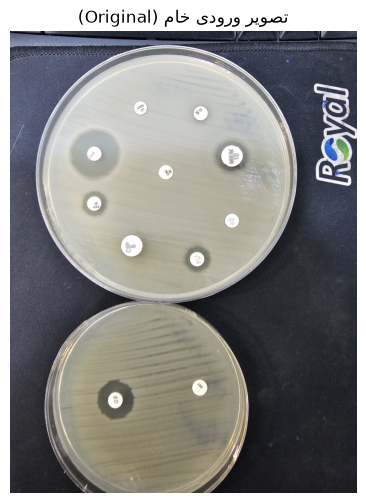

In [5]:
original_bgr = cv2.imread(cfg.image_path, cv2.IMREAD_COLOR)
if original_bgr is None:
    raise FileNotFoundError(f"Could not read image: {cfg.image_path}")

base_gray = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2GRAY)
show(cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB), cfg.input_image_title, cfg=cfg)


## ۴) تشخیص همه‌ی ظرف‌های پتری (بازطراحی — چند-پتری، دایره/مربع/فال‌بک عمومی)
برخلاف نسخه‌ی قبلی که فقط بهترین کاندید را نگه می‌داشت، این نسخه همه‌ی پتری‌های معتبر تصویر را برمی‌گرداند (`dishes`) و هر ماژول بعدی روی همه‌ی آن‌ها اجرا و خروجی‌شان را جداگانه نمایش می‌دهد. شکل هر پتری می‌تواند دایره‌ای، مربعی/مستطیلی یا (در صورت نامشخص بودن) صرفاً یک ناحیه‌ی foreground پایدار جدا از پس‌زمینه باشد.

In [ ]:
# ── ماژول ۴ (بازطراحی دوم) — تشخیص همه‌ی ظرف‌های پتری: segmentation ناحیه‌ای ──
def _detect_petri_dishes_edge_fallback(image_gray, cfg, r_lo, r_hi, s_min, diag_len, img_cx, img_cy):
    """
    مسیر قدیمی (Canny+Contour+HoughCircles) — فقط به‌عنوان آخرین fallback، وقتی
    segmentation ناحیه‌ای (روش اصلی جدید) هیچ کاندیدی پیدا نکند. روی عکس‌های واقعی این
    مسیر هم کند است (HoughCircles با بازه‌ی شعاع وسیع) و هم کمتر قابل‌اتکا (به پیوستگی
    مرز در نقشه‌ی Canny وابسته است)، به همین دلیل دیگر مسیر پیش‌فرض نیست.
    """
    h, w = image_gray.shape[:2]

    def _score(cx, cy, r_equiv, shape_score, solidity):
        center_score = 1.0 - min(1.0, float(np.hypot(cx - img_cx, cy - img_cy)) / (0.5 * diag_len))
        border_margin = min(cx, cy, w - cx, h - cy) - r_equiv
        border_score = float(np.clip(0.5 + border_margin / (0.10 * s_min), 0.0, 1.0))
        r_mid = 0.5 * (r_lo + r_hi)
        radius_score = 1.0 - min(1.0, abs(r_equiv - r_mid) / max(r_hi - r_mid, 1e-6))
        score = (cfg.dish_detect_w_circularity * shape_score +
                 cfg.dish_detect_w_solidity * solidity +
                 cfg.dish_detect_w_center * center_score +
                 cfg.dish_detect_w_border * border_score +
                 cfg.dish_detect_w_radius * radius_score)
        return float(np.clip(score, 0.0, 1.0))

    norm = cv2.normalize(image_gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    k = _safe_odd_ksize(cfg.dish_detect_blur_ksize)
    blur = cv2.GaussianBlur(norm, (k, k), 0)

    med = float(np.median(blur))
    lo_t = int(max(0.0, (1.0 - cfg.dish_detect_canny_sigma) * med))
    hi_t = int(min(255.0, (1.0 + cfg.dish_detect_canny_sigma) * med))
    if hi_t <= lo_t:
        hi_t = lo_t + 1
    edges = cv2.Canny(blur, lo_t, hi_t)

    close_k = _safe_odd_ksize(int(round(cfg.dish_detect_closing_frac * s_min)), minimum=3)
    edges_closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, elliptical_kernel(close_k))
    contours, _ = cv2.findContours(edges_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = []
    for cnt in contours:
        m = contour_shape_metrics(cnt)
        r_equiv = m["r_equiv"]
        if not (r_lo <= r_equiv <= r_hi):
            continue
        if m["area"] < np.pi * (r_lo ** 2) * 0.2:
            continue

        is_round = m["circularity"] >= cfg.dish_detect_min_circularity
        is_rect = (m["rectangularity"] >= cfg.dish_detect_min_rectangularity and
                   m["aspect_ratio"] <= cfg.dish_detect_max_aspect_ratio)
        is_generic = m["solidity"] >= cfg.dish_detect_min_solidity
        if not (is_round or is_rect or is_generic):
            continue

        if is_round and is_rect:
            method = "edge_round" if m["circularity"] >= m["rectangularity"] else "edge_rect"
        elif is_round:
            method = "edge_round"
        elif is_rect:
            method = "edge_rect"
        else:
            method = "edge_generic"

        shape_score = max(m["circularity"] if is_round else 0.0,
                          m["rectangularity"] if is_rect else 0.0,
                          m["solidity"] * 0.8 if is_generic else 0.0)
        (cx, cy), _ = cv2.minEnclosingCircle(cnt)
        score = _score(cx, cy, r_equiv, shape_score, m["solidity"])
        candidates.append({
            "x": float(cx), "y": float(cy), "r": r_equiv,
            "score": score, "method": method, "contour": cnt,
            "circularity": m["circularity"], "solidity": m["solidity"],
            "fill_ratio": m["rectangularity"],
        })

    if cfg.dish_detect_use_hough_fallback:
        circles = cv2.HoughCircles(
            blur, cv2.HOUGH_GRADIENT,
            dp=cfg.dish_detect_hough_dp, minDist=max(2.0 * r_lo, 1.0),
            param1=cfg.dish_detect_hough_param1, param2=cfg.dish_detect_hough_param2,
            minRadius=int(r_lo), maxRadius=int(r_hi)
        )
        if circles is not None:
            edge_band = cv2.dilate(edges, np.ones((15, 15), np.uint8))
            hough_angles = np.linspace(0.0, 2.0 * np.pi, 180, endpoint=False)
            cos_h, sin_h = np.cos(hough_angles), np.sin(hough_angles)
            for c0 in circles[0]:
                cx, cy, r = float(c0[0]), float(c0[1]), float(c0[2])
                px = np.clip(np.round(cx + r * cos_h).astype(int), 0, w - 1)
                py = np.clip(np.round(cy + r * sin_h).astype(int), 0, h - 1)
                edge_support = float(np.count_nonzero(edge_band[py, px])) / float(len(hough_angles))
                if edge_support < cfg.dish_detect_hough_min_edge_support:
                    continue
                # نکته: edge_support همین الان به‌عنوان یک آستانه‌ی پذیرش (gate) اعمال شده؛
                # ضرب دوباره‌ی آن در امتیاز، کاندیدهای Hough را به‌طور غیرمنصفانه در برابر
                # کاندیدهای segmentation ناحیه‌ای (که چنین تخفیفی ندارند) کم‌امتیاز می‌کند —
                # به‌خصوص وقتی Hough به‌عنوان تاییدکننده برای موارد مبهم فراخوانی می‌شود.
                score = _score(cx, cy, r, 0.90, 0.90)
                candidates.append({
                    "x": cx, "y": cy, "r": r,
                    "score": score, "method": "hough_fallback", "contour": None,
                    "circularity": 0.90, "solidity": 0.90, "fill_ratio": 0.90,
                })

    return candidates


def _region_candidates_from_threshold(image_gray, thr_value, method_prefix, cfg,
                                      r_lo, r_hi, s_min, diag_len, img_cx, img_cy):
    """
    یک آستانه‌ی سراسری مشخص را روی تصویر اعمال می‌کند و کاندیدهای پتری را از مولفه‌های
    متصل حاصل استخراج می‌کند. جدا شدن این منطق در یک تابع، امکان تلاش با چند سطح آستانه
    (مثلاً هم t1 و هم t2 از multi-Otsu) را بدون تکرار کد فراهم می‌کند — چون آستانه‌ی سراسری
    بهینه گاهی کمی از مرز واقعی پتری بیرون می‌زند (خصوصاً وقتی بافت آگار نزدیک تیرگی
    پس‌زمینه باشد) و امتحان یک آستانه‌ی سخت‌گیرانه‌تر (t2) می‌تواند مرز تمیزتری بدهد.
    """
    h, w = image_gray.shape[:2]
    fg_mask = (image_gray >= max(thr_value, 1)).astype(np.uint8) * 255

    close_k = _safe_odd_ksize(int(round(cfg.dish_detect_region_close_frac * s_min)), minimum=3)
    fg_closed = cv2.morphologyEx(fg_mask, cv2.MORPH_CLOSE, elliptical_kernel(close_k))

    region_contours, _ = cv2.findContours(fg_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    def _score(cx, cy, r_equiv, shape_score, solidity):
        center_score = 1.0 - min(1.0, float(np.hypot(cx - img_cx, cy - img_cy)) / (0.5 * diag_len))
        border_margin = min(cx, cy, w - cx, h - cy) - r_equiv
        border_score = float(np.clip(0.5 + border_margin / (0.10 * s_min), 0.0, 1.0))
        r_mid = 0.5 * (r_lo + r_hi)
        radius_score = 1.0 - min(1.0, abs(r_equiv - r_mid) / max(r_hi - r_mid, 1e-6))
        score = (cfg.dish_detect_w_circularity * shape_score +
                 cfg.dish_detect_w_solidity * solidity +
                 cfg.dish_detect_w_center * center_score +
                 cfg.dish_detect_w_border * border_score +
                 cfg.dish_detect_w_radius * radius_score)
        return float(np.clip(score, 0.0, 1.0))

    candidates: List[Dict[str, Any]] = []
    for cnt in region_contours:
        area = cv2.contourArea(cnt)
        r_equiv0 = float(np.sqrt(max(area, 0.0) / np.pi))
        if r_equiv0 < r_lo * 0.5:
            continue

        m = contour_shape_metrics(cnt)
        r_equiv = m["r_equiv"]
        if not (r_lo <= r_equiv <= r_hi):
            continue

        is_round = m["circularity"] >= cfg.dish_detect_min_circularity
        is_rect = (m["rectangularity"] >= cfg.dish_detect_min_rectangularity and
                   m["aspect_ratio"] <= cfg.dish_detect_max_aspect_ratio)
        is_generic = m["solidity"] >= cfg.dish_detect_min_solidity
        if not (is_round or is_rect or is_generic):
            continue

        if is_round and is_rect:
            method = f"{method_prefix}_round" if m["circularity"] >= m["rectangularity"] else f"{method_prefix}_rect"
        elif is_round:
            method = f"{method_prefix}_round"
        elif is_rect:
            method = f"{method_prefix}_rect"
        else:
            method = f"{method_prefix}_generic"

        shape_score = max(m["circularity"] if is_round else 0.0,
                          m["rectangularity"] if is_rect else 0.0,
                          m["solidity"] * 0.8 if is_generic else 0.0)
        (cx, cy), _ = cv2.minEnclosingCircle(cnt)
        score = _score(cx, cy, r_equiv, shape_score, m["solidity"])
        candidates.append({
            "x": float(cx), "y": float(cy), "r": r_equiv,
            "score": score, "method": method, "contour": cnt,
            "circularity": m["circularity"], "solidity": m["solidity"],
            "fill_ratio": m["rectangularity"],
        })

    return candidates


def detect_all_petri_dishes(image_gray: np.ndarray, cfg) -> List[Dict[str, Any]]:
    """
    تشخیص همه‌ی ظرف‌های پتری با segmentation ناحیه‌ای (نه لبه‌محور) به‌عنوان روش اصلی:
      ۱) آستانه‌گذاری دوکلاسه‌ی سراسری (Multi-level Otsu) برای جدا کردن (آگار+برچسب
         دیسک) از پس‌زمینه — نیازی به پیوستگی مرز ندارد، پس در برابر نور ناهموار،
         بازتاب و پس‌زمینه‌ی شلوغ عکس‌های واقعی robust است؛ و در چند صدم ثانیه اجرا
         می‌شود (برخلاف HoughCircles با بازه‌ی شعاع وسیع که ده‌ها ثانیه طول می‌کشد).
         هر دو آستانه‌ی خروجی Multi-Otsu (t1: مرز پس‌زمینه/آگار، t2: مرز آگار/برچسب
         روشن) امتحان می‌شوند — t1 معمولاً کل ظرف را می‌گیرد ولی گاهی کمی از مرز واقعی
         بیرون می‌زند؛ t2 سخت‌گیرانه‌تر است و در آن موارد مرز تمیزتری می‌دهد.
      ۲) closing سبک برای پر کردن حفره‌های ریز بافت آگار/پس‌زمینه.
      ۳) هر مولفه‌ی متصل هم‌اندازه‌ی یک پتری = یک کاندید.
      ۴) مسیر قدیمی Canny+Contour+Hough فقط وقتی segmentation ناحیه‌ای هیچ کاندید
         دایره‌ای/مربعیِ قابل‌اطمینانی پیدا نکند (یا هیچ کاندیدی نداشته باشد)، به‌عنوان
         آخرین fallback/تاییدکننده اجرا می‌شود.
    خروجی هر کاندید ماسک واقعی‌اش را دارد (نه یک دایره‌ی اجباری)، پس هم برای پتری‌های
    دایره‌ای و هم مربعی/مستطیلی/نامشخص به‌درستی کار می‌کند.
    """
    if image_gray is None or image_gray.size == 0:
        return []

    h, w = image_gray.shape[:2]
    s_min = float(min(h, w))
    diag_len = float(np.hypot(h, w))
    r_lo = cfg.dish_detect_min_radius_frac * s_min
    r_hi = cfg.dish_detect_max_radius_frac * s_min
    img_cx, img_cy = w * 0.5, h * 0.5

    image_gray_corrected = illumination_normalize(image_gray, cfg.dish_detect_illum_kernel_frac)

    small = cv2.resize(image_gray_corrected, (400, 400))
    t1, t2 = _multi_otsu_threshold(small)

    candidates: List[Dict[str, Any]] = _region_candidates_from_threshold(
        image_gray_corrected, t1, "region", cfg, r_lo, r_hi, s_min, diag_len, img_cx, img_cy
    )
    if t2 > t1:
        candidates = candidates + _region_candidates_from_threshold(
            image_gray_corrected, t2, "region2", cfg, r_lo, r_hi, s_min, diag_len, img_cx, img_cy
        )

    # اگر segmentation ناحیه‌ای هیچ کاندیدی پیدا نکرد، یا همه‌ی کاندیدها فقط از مسیر
    # عمومی/کم‌اعتماد (region*_generic — نه دایره‌ای/مربعی تشخیص داده شده، احتمالاً چند
    # ناحیه‌ی ادغام‌شده مثل دو پتری چسبیده) عبور کردند، مسیر لبه‌محور هم به‌عنوان
    # تاییدکننده/تکمیل‌کننده اجرا و کاندیدهایش اضافه می‌شود؛ امتیازدهی+NMS موجود تصمیم
    # می‌گیرد کدام مجموعه بهتر است. این یعنی هزینه‌ی Hough فقط برای موارد واقعاً مبهم
    # پرداخت می‌شود، نه برای هر عکس.
    needs_edge_check = (not candidates) or all(c["method"].endswith("_generic") for c in candidates)
    if needs_edge_check:
        candidates = candidates + _detect_petri_dishes_edge_fallback(
            image_gray_corrected, cfg, r_lo, r_hi, s_min, diag_len, img_cx, img_cy
        )

    accepted = [c for c in candidates if c["score"] >= cfg.dish_detect_accept_confidence]
    deduped = nms_circles(accepted, min_center_dist=0.0)

    # فیلتر containment: یک ظرف پتری فیزیکی نمی‌تواند داخل ظرف پتری دیگری باشد. این
    # فیلتر مخصوصاً برای fallback لبه‌محور (Hough) لازم است — روی عکس‌های واقعی مشخص شد
    # هاله‌های تیره‌ی دور دیسک‌ها می‌توانند مرزهای دایره‌ای کاذبی در مقیاسی نزدیک به خودِ
    # پتری ایجاد کنند که از آستانه‌ی edge_support هم عبور می‌کنند؛ چون این کاندیدهای کاذب
    # هم‌مرکز با پتری واقعی نیستند، NMS معمولی (مبتنی بر فاصله‌ی مرکز) آن‌ها را حذف
    # نمی‌کند. این‌جا هر کاندید کم‌امتیازتر که عمدتاً داخل یک کاندید پرامتیازتر دیگر باشد
    # (نسبت هم‌پوشانی نسبت به دایره‌ی کوچک‌تر، فرم بسته‌ی موجود در توابع کمکی) حذف می‌شود.
    deduped.sort(key=lambda c: (-c["score"], c["x"], c["y"], c["r"]))
    kept: List[Dict[str, Any]] = []
    for c in deduped:
        contained = any(
            _circle_overlap_ratio(c["x"], c["y"], c["r"], k["x"], k["y"], k["r"]) >= cfg.dish_containment_reject_frac
            for k in kept
        )
        if not contained:
            kept.append(c)
    deduped = kept

    results = []
    for c in deduped:
        cx_i, cy_i, r_i = int(round(c["x"])), int(round(c["y"])), int(round(c["r"]))
        if c["contour"] is not None:
            mask = mask_from_contour((h, w), c["contour"])
        else:
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.circle(mask, (cx_i, cy_i), r_i, 255, -1)

        mask_area = float(np.count_nonzero(mask))
        r_equiv_final = float(np.sqrt(mask_area / np.pi)) if mask_area > 0 else float(r_i)

        results.append({
            "status": "ok", "confidence": float(c["score"]), "mask": mask,
            "center": (cx_i, cy_i), "radius": r_equiv_final, "method": c["method"],
        })

    results.sort(key=lambda d: (-d["confidence"], d["center"][0], d["center"][1]))
    return results


petri_results = detect_all_petri_dishes(base_gray, cfg)

dishes: List[Dict[str, Any]] = []

if petri_results:
    for pr in petri_results:
        cx_g, cy_g = pr["center"]
        r_g = pr["radius"]
        pad = cfg.dish_padding_px

        x0 = max(0, int(round(cx_g - r_g)) - pad)
        y0 = max(0, int(round(cy_g - r_g)) - pad)
        x1 = min(base_gray.shape[1], int(round(cx_g + r_g)) + pad)
        y1 = min(base_gray.shape[0], int(round(cy_g + r_g)) + pad)

        d_roi_gray = base_gray[y0:y1, x0:x1]
        d_offset_xy = (x0, y0)
        d_mask_roi = pr["mask"][y0:y1, x0:x1].copy()

        if cfg.dish_mask_erode_before_use:
            erode_k = elliptical_kernel(cfg.dish_mask_erode_kernel_size)
            d_mask_roi = cv2.erode(d_mask_roi, erode_k, iterations=cfg.dish_mask_erode_iterations)

        d_roi_gray_masked = _mask_nonzero(d_roi_gray, d_mask_roi)
        d_center_roi_xy = (int(round(cx_g)) - x0, int(round(cy_g)) - y0)
        d_radius_px = float(r_g)

        dishes.append({
            "index": len(dishes) + 1,
            "bbox": (x0, y0, x1 - x0, y1 - y0),
            "roi_gray": d_roi_gray,
            "roi_offset_xy": d_offset_xy,
            "mask_full": pr["mask"],
            "processing_mask_roi": d_mask_roi,
            "roi_gray_masked": d_roi_gray_masked,
            "center_roi_xy": d_center_roi_xy,
            "center_global_xy": (int(round(cx_g)), int(round(cy_g))),
            "radius_px": d_radius_px,
            "diameter_px": 2.0 * d_radius_px,
            "confidence": float(pr["confidence"]),
            "method": pr["method"],
            "status": "ok",
        })
        print(f"[Module 4] پتری #{len(dishes)} با روش '{pr['method']}' یافت شد | "
              f"confidence={pr['confidence']:.2f} | radius≈{d_radius_px:.0f}px")
else:
    d_mask_roi_fb = _make_full_mask_like(base_gray)
    dishes.append({
        "index": 1,
        "bbox": (0, 0, base_gray.shape[1], base_gray.shape[0]),
        "roi_gray": base_gray,
        "roi_offset_xy": (0, 0),
        "mask_full": d_mask_roi_fb,
        "processing_mask_roi": d_mask_roi_fb,
        "roi_gray_masked": base_gray.copy(),
        "center_roi_xy": (base_gray.shape[1] // 2, base_gray.shape[0] // 2),
        "center_global_xy": (base_gray.shape[1] // 2, base_gray.shape[0] // 2),
        "radius_px": 0.5 * float(min(base_gray.shape[:2])),
        "diameter_px": float(min(base_gray.shape[:2])),
        "confidence": 0.0,
        "method": "none",
        "status": "fallback_full_frame",
    })
    if cfg.dish_fallback_use_full_frame:
        print(cfg.dish_fallback_message_full_frame)

vis = original_bgr.copy()
palette = [(0, 255, 0), (255, 165, 0), (0, 200, 255), (255, 0, 255), (0, 128, 255)]
for i, dish in enumerate(dishes):
    color = palette[i % len(palette)]
    if dish["method"] != "none":
        outline_contours, _ = cv2.findContours(dish["mask_full"], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(vis, outline_contours, -1, color, 4)
    bx, by, bw, bh = dish["bbox"]
    cv2.rectangle(vis, (bx, by), (bx + bw, by + bh), color, 2)
    cv2.putText(vis, f"#{dish['index']}", (bx + 8, by + 36),
                cv2.FONT_HERSHEY_SIMPLEX, 1.1, color, 3, cv2.LINE_AA)

show(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB),
     f"Dish Detection — {len(dishes)} پتری یافت شد", cfg=cfg)


## 4.1) ماژول تشخیص دقیق‌تر پتری (per-dish)

In [ ]:
# ── ماژول ۴.۱ — استخراج ماسک دقیق و فید لبه‌های هر پتری (per-dish) ──────────
for dish in dishes:
    roi_gray_masked = dish["roi_gray_masked"]
    processing_mask_roi = dish["processing_mask_roi"]

    if roi_gray_masked is None or roi_gray_masked.size == 0:
        raise ValueError(f"ماژول ۴.۱ (پتری #{dish['index']}): roi_gray_masked معتبر نیست یا خالی است.")

    if cfg.blur_ksize and cfg.blur_ksize > 1:
        k_precise = _safe_odd_ksize(cfg.blur_ksize)
        img_blur_precise = cv2.GaussianBlur(roi_gray_masked, (k_precise, k_precise), cfg.blur_sigma)
    else:
        img_blur_precise = roi_gray_masked.copy()

    long_side_p = max(img_blur_precise.shape[:2])
    expected_dia_px = (long_side_p / float(cfg.expected_image_long_side_px)) * 60.0
    kernel_size_large = _safe_odd_ksize(int(round(cfg.tophat_kernel_scale * expected_dia_px)), minimum=3)
    tophat_kernel_l = elliptical_kernel(kernel_size_large)

    tophat_l = cv2.morphologyEx(img_blur_precise, cv2.MORPH_TOPHAT, tophat_kernel_l)
    tophat_l_masked = _mask_nonzero(tophat_l, processing_mask_roi)

    block_l = _safe_odd_ksize(cfg.adaptive_block_size, minimum=3)
    thr_l = cv2.adaptiveThreshold(
        tophat_l_masked, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, block_l, int(cfg.adaptive_C)
    )
    thr_l = cv2.bitwise_and(thr_l, processing_mask_roi)

    close_k_large = elliptical_kernel(cfg.morph_closing_ksize_large)
    thr_closed_large = cv2.morphologyEx(thr_l, cv2.MORPH_CLOSE, close_k_large)
    thr_closed_large = cv2.bitwise_and(thr_closed_large, processing_mask_roi)

    open_k_large = elliptical_kernel(cfg.morph_opening_ksize_large)
    thr_open_large = cv2.morphologyEx(thr_closed_large, cv2.MORPH_OPEN, open_k_large)
    thr_open_large = cv2.bitwise_and(thr_open_large, processing_mask_roi)

    precise_dish_mask = _ensure_uint8_binary(thr_open_large)
    mask_white_pixels = int(np.count_nonzero(precise_dish_mask))
    mask_is_trivial = (mask_white_pixels == 0) or (mask_white_pixels == precise_dish_mask.size)

    if not mask_is_trivial:
        roi_gray_precise_faded = apply_border_fade_from_mask(
            roi_gray_masked, precise_dish_mask, cfg.precise_dish_mask_fade_px
        )
        precise_dish_result = {"status": "mask_guided_fade", "mask_white_pixels": mask_white_pixels,
                               "used_full_image_fallback": False}
        print(f"[Module 4.1 | Dish #{dish['index']}] ماسک دقیق ساخته شد و فید مرز اعمال گردید.")
    else:
        fallback_reason = "empty_mask" if mask_white_pixels == 0 else "full_white_mask"
        if cfg.precise_dish_fallback_to_image_border_fade:
            roi_gray_precise_faded = apply_border_fade(roi_gray_masked, cfg.crop_border_fade_px)
            fallback_mode = "full_roi_border_fade"
        else:
            roi_gray_precise_faded = roi_gray_masked.copy()
            fallback_mode = "no_fade"
        precise_dish_result = {"status": f"{fallback_reason}_fallback", "mask_white_pixels": mask_white_pixels,
                               "used_full_image_fallback": True, "fallback_mode": fallback_mode}
        print(f"[Module 4.1 | Dish #{dish['index']} Warning] ماسک نامعتبر ({fallback_reason}). فال‌بک: {fallback_mode}")

    dish["precise_dish_mask"] = precise_dish_mask
    dish["precise_dish_result"] = precise_dish_result
    dish["roi_gray_precise_faded"] = roi_gray_precise_faded

    show(roi_gray_precise_faded, f"[Dish #{dish['index']}] ROI فیدشده (ماسک دقیق پتری)", cfg=cfg)


## ۵) ماژول: White Top-Hat Transform
جدا کردن دیسک از نور نامنظم پس‌زمینه.

In [ ]:
# ── ماژول ۵ — Disk-Specific Feature Image (per-dish) ─────────────────────────
def build_disk_feature_image(gray_roi: np.ndarray,
                             dish_mask: np.ndarray,
                             dish_diameter_px: float,
                             cfg) -> Dict[str, Any]:
    """
    ساخت تصویر ویژه‌ی دیسک سفید:
      ۱) تخمین روشنایی پس‌زمینه با Gaussian بزرگ و Morphological Opening
      ۲) White Top-Hat + کنتراست محلی مثبت
      ۳) ترکیب با نرمال‌سازی robust (percentile-based)
    ابعاد همه‌ی کرنل‌ها از dish_diameter_px و بازه نسبی دیسک مشتق می‌شوند.
    """
    out = {"feature_image": None, "threshold_mask": None,
           "diagnostics": {}, "status": "error_invalid_input"}

    if gray_roi is None or gray_roi.size == 0 or dish_diameter_px <= 0:
        return out

    mask_u8 = _ensure_uint8_binary(dish_mask) if dish_mask is not None \
        else np.full(gray_roi.shape[:2], 255, dtype=np.uint8)

    inside = mask_u8 > 0
    if not np.any(inside):
        out["status"] = "error_empty_mask"
        return out

    bounds = disk_radius_bounds_px(dish_diameter_px, cfg)
    disk_d_min, disk_d_max = bounds["d_min"], bounds["d_max"]

    blur_k = _safe_odd_ksize(int(round(cfg.disk_feature_blur_frac * disk_d_min)), minimum=3)
    img = cv2.GaussianBlur(gray_roi, (blur_k, blur_k), 0)

    bg_k = _safe_odd_ksize(int(round(cfg.disk_feature_bg_kernel_scale * disk_d_max)), minimum=3)
    tophat_k = _safe_odd_ksize(int(round(cfg.disk_feature_tophat_kernel_scale * disk_d_max)), minimum=3)

    tophat = cv2.morphologyEx(img, cv2.MORPH_TOPHAT, elliptical_kernel(tophat_k))
    background_gauss = cv2.GaussianBlur(img, (bg_k, bg_k), 0)
    local_contrast = cv2.subtract(img, background_gauss)

    def _robust01(x: np.ndarray) -> np.ndarray:
        vals = x[inside].astype(np.float32)
        if vals.size == 0:
            return np.zeros(x.shape, dtype=np.float32)
        p_lo, p_hi = np.percentile(vals, [cfg.disk_feature_norm_p_lo, cfg.disk_feature_norm_p_hi])
        if p_hi <= p_lo:
            return np.zeros(x.shape, dtype=np.float32)
        out01 = np.clip((x.astype(np.float32) - p_lo) / (p_hi - p_lo), 0.0, 1.0)
        out01[~inside] = 0.0
        return out01

    combined = (cfg.disk_feature_w_tophat * _robust01(tophat) +
                cfg.disk_feature_w_contrast * _robust01(local_contrast))
    combined = np.clip(combined / max(cfg.disk_feature_w_tophat + cfg.disk_feature_w_contrast, 1e-6), 0.0, 1.0)

    # فیلتر انتخابیِ مقیاس: opening خاکستری با کرنل کوچک‌تر از کوچک‌ترین دیسک مجاز، برای
    # حذف بلاب‌های روشنِ کوچک‌تر (نویز درخشش/بازتاب) بدون تار کردن لبه‌ی دیسک‌های واقعی —
    # opening روی بلاب‌های بزرگ‌تر از کرنل تقریباً بی‌اثر است (فقط کمی می‌فرساید و دوباره
    # می‌سازد)، برخلاف Gaussian blur که همه‌ی مقیاس‌ها را یکسان صاف می‌کند.
    open_k = _safe_odd_ksize(int(round(cfg.disk_feature_denoise_open_frac * bounds["r_min"])), minimum=3)
    combined_u8 = (combined * 255.0).astype(np.uint8)
    combined_u8 = cv2.morphologyEx(combined_u8, cv2.MORPH_OPEN, elliptical_kernel(open_k))
    combined = combined_u8.astype(np.float32) / 255.0

    feature = (combined * 255.0).astype(np.uint8)
    feature = _mask_nonzero(feature, mask_u8)

    vals_in = feature[inside]
    thr_val = float(np.percentile(vals_in, cfg.disk_feature_thr_percentile))
    threshold_mask = np.zeros_like(feature)
    threshold_mask[(feature >= max(thr_val, 1.0)) & inside] = 255

    coverage = float(np.count_nonzero(threshold_mask)) / max(int(np.count_nonzero(inside)), 1)
    status = "ok" if coverage <= cfg.disk_feature_max_coverage else "low_contrast"

    out.update({
        "feature_image": feature,
        "threshold_mask": threshold_mask,
        "status": status,
        "diagnostics": {
            "blur_k": blur_k, "bg_k": bg_k, "tophat_k": tophat_k,
            "disk_d_min_px": disk_d_min, "disk_d_max_px": disk_d_max,
            "threshold_value": thr_val, "mask_coverage": coverage,
        },
    })
    return out


for dish in dishes:
    roi_gray_precise_faded = dish["roi_gray_precise_faded"]
    processing_mask_roi = dish["processing_mask_roi"]
    dish_diameter_px = dish["diameter_px"]

    if roi_gray_precise_faded is None or roi_gray_precise_faded.size == 0:
        raise ValueError(f"ماژول ۵ (پتری #{dish['index']}): roi_gray_precise_faded معتبر نیست.")

    disk_feature_result = build_disk_feature_image(
        roi_gray_precise_faded, processing_mask_roi, dish_diameter_px, cfg
    )
    if disk_feature_result["feature_image"] is None:
        raise RuntimeError(f"ماژول ۵ (پتری #{dish['index']}): ساخت feature ناموفق ({disk_feature_result['status']}).")

    dish["disk_feature_image"] = disk_feature_result["feature_image"]
    dish["disk_feature_mask"] = disk_feature_result["threshold_mask"]
    dish["disk_feature_diag"] = disk_feature_result["diagnostics"]

    d = disk_feature_result["diagnostics"]
    print(f"[Module 5 | Dish #{dish['index']}] status={disk_feature_result['status']} | "
          f"bg={d['bg_k']} tophat={d['tophat_k']} | coverage={d['mask_coverage']:.3f}")

    show(dish["disk_feature_image"], f"[Dish #{dish['index']}] Disk Feature Image", cfg=cfg)
    show(dish["disk_feature_mask"], f"[Dish #{dish['index']}] Disk Feature Threshold Mask", cfg=cfg)


## ۶) ماژول: Adaptive Threshold
تبدیل تصویر Top-Hat به تصویر باینری با آستانه‌ی محلی.

In [ ]:
# ── ماژول ۶ (بازطراحی) — آستانه‌گذاری Global-Percentile (per-dish) ──────────
# آستانه‌گذاری محلی (Adaptive) روی تصویر feature در حضور هاله‌های پهن، عملاً
# نیمی از هر پنجره را به‌اشتباه «فورگراند» علامت می‌زند (گرادیان نرم هاله، نه
# نویز موضعی). جایگزین: آستانه‌ی سراسری robust (percentile) نسبت به آمار
# خودِ پتری — هم‌راستا با منطق ماژول ۵ اما با percentile کمی مداراگرانه‌تر
# (recall بیشتر) چون خروجی این ماژول با closing/opening/DT پالایش خواهد شد.
for dish in dishes:
    roi_gray = dish["roi_gray"]
    processing_mask_roi = dish["processing_mask_roi"]
    disk_feature_image = dish["disk_feature_image"]

    if roi_gray is None or roi_gray.size == 0:
        raise RuntimeError(f"ماژول ۶ (پتری #{dish['index']}): ROI معتبر موجود نیست.")

    inside = processing_mask_roi > 0
    vals_in = disk_feature_image[inside]
    thr_val = float(np.percentile(vals_in, cfg.adaptive_percentile)) if vals_in.size > 0 else 255.0

    thr = np.zeros_like(disk_feature_image)
    thr[(disk_feature_image >= max(thr_val, 1.0)) & inside] = 255

    dish["thr"] = thr
    dish["adaptive_threshold_value"] = thr_val
    show(thr, f"[Dish #{dish['index']}] Global-Percentile Threshold "
              f"(p={cfg.adaptive_percentile}, val≈{thr_val:.0f})", cfg=cfg)


## ۷) ماژول: Morphological Closing — راه‌حل ۱ (تنها راه‌حل فعال)
پُر کردن حفره‌های ناشی از نوشته‌ی روی دیسک، قبل از Opening.

In [ ]:
# ── ماژول ۷ — Morphological Closing (شاخه کوچک، کرنل نسبی) — per-dish ───────
for dish in dishes:
    thr = dish["thr"]
    processing_mask_roi = dish["processing_mask_roi"]
    if thr is None or thr.size == 0:
        raise ValueError(f"ماژول ۷ (پتری #{dish['index']}): تصویر باینری ورودی معتبر نیست.")

    bounds = disk_radius_bounds_px(dish["diameter_px"], cfg)
    close_k = _safe_odd_ksize(int(round(cfg.morph_closing_frac_small * bounds["d_min"])), minimum=3)
    close_kernel_small = elliptical_kernel(close_k)

    thr_closed_small = cv2.morphologyEx(thr, cv2.MORPH_CLOSE, close_kernel_small)
    thr_closed_small = cv2.bitwise_and(thr_closed_small, processing_mask_roi)

    dish["thr_closed_small"] = thr_closed_small
    show(thr_closed_small, f"[Dish #{dish['index']}] Closing (kernel={close_k}px)", cfg=cfg)


## ۸) ماژول: Morphological Opening
حذف نویزهای ریز باقی‌مانده.

In [ ]:
# ── ماژول ۸ — Morphological Opening (شاخه کوچک، کرنل نسبی) — per-dish ───────
for dish in dishes:
    thr_closed_small = dish["thr_closed_small"]
    processing_mask_roi = dish["processing_mask_roi"]
    if thr_closed_small is None or thr_closed_small.size == 0:
        raise ValueError(f"ماژول ۸ (پتری #{dish['index']}): thr_closed_small معتبر نیست.")

    bounds = disk_radius_bounds_px(dish["diameter_px"], cfg)
    open_k = _safe_odd_ksize(int(round(cfg.morph_opening_frac_small * bounds["d_min"])), minimum=3)
    open_kernel_small = elliptical_kernel(open_k)

    thr_open_small = cv2.morphologyEx(thr_closed_small, cv2.MORPH_OPEN, open_kernel_small)
    thr_open_small = cv2.bitwise_and(thr_open_small, processing_mask_roi)

    dish["thr_open_small"] = thr_open_small
    show(thr_open_small, f"[Dish #{dish['index']}] Opening (kernel={open_k}px, ورودی ماژول ۹)", cfg=cfg)


## 8.5) بررسی خودکار محتمل‌بودن پتری (Self-Check)

In [ ]:
# ── ماژول ۸.۵ (جدید) — Petri Plausibility Self-Check ────────────────────────
# مشاهده‌شده روی عکس‌های واقعی: مسیر fallback لبه‌محور (Hough) در ماژول ۴ گاهی یک ناحیه‌ی
# کاملاً بی‌ربط (بازتاب نور، بافت پس‌زمینه، برچسب دوربین) را به‌عنوان «پتری» می‌پذیرد —
# چون تاییدِ آن مسیر (edge_support) از همان نقشه‌ی Canny ساخته شده که HoughCircles خودش
# کاندید را از آن استخراج کرده (یک تاییدِ خودارجاع، نه مستقل). این ماژول یک تاییدِ کاملاً
# مستقل و ارزان اضافه می‌کند: آیا داخل این «پتری» حداقل یک بلاب هم‌اندازه‌ی دیسک واقعی
# (thr_open_small بعد از closing/opening ماژول ۷/۸) وجود دارد؟ یک پتری واقعی — طبق تعریف
# خودِ مسئله — همیشه حداقل چند دیسک آنتی‌بیوتیک دارد؛ نبودِ کامل چنین ساختاری نشانه‌ی قوی
# false positive است، نه یک پتری واقعی با دیسک کم.
kept_dishes: List[Dict[str, Any]] = []
for dish in dishes:
    bounds = disk_radius_bounds_px(dish["diameter_px"], cfg)
    margin = 1.0 + cfg.disk_hough_radius_margin
    r_min = bounds["r_min"] / margin
    r_max = bounds["r_max"] * margin
    area_min = float(np.pi * (r_min ** 2))
    area_max = float(np.pi * (r_max ** 2))

    num_labels, _labels, stats, _ = cv2.connectedComponentsWithStats(
        _ensure_uint8_binary(dish["thr_open_small"])
    )
    plausible = sum(
        1 for i in range(1, num_labels)
        if area_min <= float(stats[i, cv2.CC_STAT_AREA]) <= area_max
    )
    dish["plausible_disk_blob_count"] = plausible

    if plausible >= cfg.petri_min_plausible_disk_blobs:
        dish["petri_plausibility"] = "ok"
        kept_dishes.append(dish)
        print(f"[Dish #{dish['index']}] Self-Check: {plausible} بلاب هم‌اندازه‌ی دیسک یافت شد → پتری معتبر.")
    else:
        dish["petri_plausibility"] = "rejected_no_disk_evidence"
        print(f"[Dish #{dish['index']}] Self-Check: {plausible} بلاب هم‌اندازه‌ی دیسک یافت شد "
              f"(آستانه={cfg.petri_min_plausible_disk_blobs}) → به‌عنوان پتری کاذب رد شد.")

rejected_count = len(dishes) - len(kept_dishes)
dishes = kept_dishes
if rejected_count > 0:
    print(f"[Module 8.5] {rejected_count} پتری کاذب رد شد؛ {len(dishes)} پتری معتبر باقی ماند.")
else:
    print(f"[Module 8.5] همه‌ی {len(dishes)} پتری تاییدشده معتبر شناخته شدند.")


## ۹) ماژول: Distance Transform
هر پیکسل روشن، فاصله‌اش تا نزدیک‌ترین پیکسل تیره (لبه) را نشان می‌دهد.

In [ ]:
# ── ماژول ۹ — Distance Transform + Gaussian Filtering (per-dish) ────────────
for dish in dishes:
    thr_open_small = dish["thr_open_small"]
    processing_mask_roi = dish["processing_mask_roi"]
    if thr_open_small is None or thr_open_small.size == 0:
        raise ValueError(f"ماژول ۹ (پتری #{dish['index']}): thr_open_small معتبر نیست.")

    dist = cv2.distanceTransform(thr_open_small, cv2.DIST_L2, 3)
    dist = dist * (processing_mask_roi > 0).astype(np.float32)

    if cfg.dt_gaussian_ksize and cfg.dt_gaussian_ksize > 1:
        dt_gaussian_k = _safe_odd_ksize(cfg.dt_gaussian_ksize)
        dist_filtered = cv2.GaussianBlur(dist, (dt_gaussian_k, dt_gaussian_k), cfg.dt_gaussian_sigma)
    else:
        dist_filtered = dist.copy()

    dist_filtered = dist_filtered * (processing_mask_roi > 0).astype(np.float32)
    dist_norm = cv2.normalize(dist_filtered, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    dish["dist_filtered"] = dist_filtered
    dish["dist_norm"] = dist_norm
    show(dist_norm, f"[Dish #{dish['index']}] Distance Transform + Gaussian Filter", cmap="viridis", cfg=cfg)


## ۱۰) ماژول: نقشه‌ی هاله (Halo Gradient Map)
ورودی موردنیاز فیلتر Halo Edge Ratio در ادامه.

In [ ]:
# ── ماژول ۱۰ — نقشه‌ی هاله (Halo Gradient Map) — per-dish ───────────────────
def preprocess_for_halo(image_gray, cfg):
    blur_k = _safe_odd_ksize(cfg.halo_blur_ksize)
    median_k = _safe_odd_ksize(cfg.halo_median_ksize)

    blur = cv2.GaussianBlur(image_gray, (blur_k, blur_k), cfg.halo_blur_sigma)
    clahe = cv2.createCLAHE(clipLimit=cfg.halo_clahe_clip_limit,
                            tileGridSize=cfg.halo_clahe_tile_grid_size).apply(blur)
    median = cv2.medianBlur(clahe, median_k)
    halo_grad = cv2.morphologyEx(median, cv2.MORPH_GRADIENT, elliptical_kernel(cfg.halo_gradient_kernel_size))
    return halo_grad


for dish in dishes:
    roi_gray_precise_faded = dish["roi_gray_precise_faded"]
    processing_mask_roi = dish["processing_mask_roi"]
    if roi_gray_precise_faded is None or roi_gray_precise_faded.size == 0:
        raise ValueError(f"ماژول ۱۰ (پتری #{dish['index']}): roi_gray_precise_faded معتبر نیست.")

    halo_map = preprocess_for_halo(roi_gray_precise_faded, cfg)
    halo_map = _mask_nonzero(halo_map, processing_mask_roi)
    dish["halo_map"] = halo_map

    plt.figure(figsize=cfg.default_figsize)
    plt.imshow(halo_map, cmap="jet")
    plt.title(f"[Dish #{dish['index']}] نقشه گرادیان هاله (ورودی کمکی ماژول ۱۷)")
    plt.colorbar(label="شدت گرادیان")
    plt.axis("off")
    plt.show()


## 10.5) Disk- Specific Edge Image

In [ ]:
# ── ماژول ۱۰.۵ — Disk-Specific Edge Image (per-dish) ────────────────────────
def build_disk_edge_image(gray_img: np.ndarray,
                          disk_feature_img: np.ndarray,
                          dish_mask: np.ndarray,
                          dish_radius_px: float,
                          cfg) -> Dict[str, Any]:
    """
    تولید edge map مخصوص مرز بیرونی دیسک:
      - حذف مرز پتری با erosion نسبی روی ماسک
      - کنترل ساختارهای داخلی (نوشته‌های سیاه) با closing نسبی
      - آستانه‌های Canny از MAD (با fallback به percentile)، بدون مقدار ثابت
    """
    out = {"edge_image": None, "mask": None, "metrics": {}, "status": "error_invalid_input"}

    if gray_img is None or disk_feature_img is None or disk_feature_img.size == 0:
        return out
    if dish_radius_px <= 0:
        return out

    disk_d_min = cfg.disk_rel_diameter_min * 2.0 * dish_radius_px
    disk_d_max = cfg.disk_rel_diameter_max * 2.0 * dish_radius_px

    mask_u8 = _ensure_uint8_binary(dish_mask) if dish_mask is not None \
        else np.full(disk_feature_img.shape[:2], 255, dtype=np.uint8)
    margin_k = _safe_odd_ksize(int(round(cfg.disk_edge_dish_margin_frac * dish_radius_px)), minimum=3)
    inner_mask = cv2.erode(mask_u8, elliptical_kernel(margin_k), iterations=1)

    if np.count_nonzero(inner_mask) == 0:
        out["status"] = "error_empty_inner_mask"
        return out

    feat = _mask_nonzero(disk_feature_img, inner_mask)

    close_k = _safe_odd_ksize(int(round(cfg.disk_edge_text_close_frac * disk_d_min)), minimum=3)
    feat_closed = cv2.morphologyEx(feat, cv2.MORPH_CLOSE, elliptical_kernel(close_k))
    feat_closed = cv2.bitwise_and(feat_closed, feat_closed, mask=inner_mask)

    blur_k = _safe_odd_ksize(int(round(cfg.disk_edge_blur_frac * disk_d_min)), minimum=3)
    smooth = cv2.GaussianBlur(feat_closed, (blur_k, blur_k), 0)

    vals = smooth[inner_mask > 0].astype(np.float32)
    med = float(np.median(vals))
    mad = float(np.median(np.abs(vals - med)))
    if mad > 1e-6:
        hi_t = float(np.clip(med + cfg.disk_edge_mad_k_high * 1.4826 * mad, 10.0, 255.0))
        thr_method = "mad"
    else:
        hi_t = float(np.clip(np.percentile(vals, 90.0), 10.0, 255.0))
        thr_method = "percentile_fallback"
    lo_t = cfg.disk_edge_low_ratio * hi_t

    edges = cv2.Canny(smooth, lo_t, hi_t)
    edges = cv2.bitwise_and(edges, inner_mask)

    inside_area = max(int(np.count_nonzero(inner_mask)), 1)
    edge_density = float(np.count_nonzero(edges)) / float(inside_area)

    if edge_density < cfg.disk_edge_min_density:
        status = "weak_edges"
    elif edge_density > cfg.disk_edge_max_density:
        status = "noisy_edges"
    else:
        status = "ok"

    out.update({
        "edge_image": edges, "mask": inner_mask, "status": status,
        "metrics": {"canny_low": lo_t, "canny_high": hi_t, "thr_method": thr_method,
                   "edge_density": edge_density, "margin_k": margin_k, "close_k": close_k, "blur_k": blur_k},
    })
    return out


for dish in dishes:
    disk_edge_result = build_disk_edge_image(
        dish["roi_gray_precise_faded"], dish["disk_feature_image"],
        dish["processing_mask_roi"], dish["radius_px"], cfg
    )
    if disk_edge_result["edge_image"] is None:
        raise RuntimeError(f"ماژول ۱۰.۵ (پتری #{dish['index']}): ساخت edge ناموفق ({disk_edge_result['status']}).")

    dish["disk_edge_image"] = disk_edge_result["edge_image"]
    dish["disk_edge_inner_mask"] = disk_edge_result["mask"]

    m = disk_edge_result["metrics"]
    print(f"[Module 10.5 | Dish #{dish['index']}] status={disk_edge_result['status']} | "
          f"Canny=({m['canny_low']:.1f}, {m['canny_high']:.1f}) [{m['thr_method']}] | density={m['edge_density']:.4f}")
    show(dish["disk_edge_image"], f"[Dish #{dish['index']}] Disk-Specific Edge Image", cfg=cfg)


## ۱۱) ماژول Hough ROI-aware
این فیلتر از halo_map (خروجی ماژول ۱۰) و ماسک محدوده کننده (thr_open_large) استفاده می‌کند. در صورتی که ماسک فاقد پیکسل سفید باشد، به صورت خودکار به کل تصویر سوئیچ می‌کند.

In [ ]:
# ── ماژول ۱۱ — Hough Circle دیسک (Scale-Aware + Validation) — per-dish ─────
def run_disk_hough(feature_img: np.ndarray,
                   edge_img: Optional[np.ndarray],
                   dish_mask: np.ndarray,
                   dish_center_xy: Tuple[int, int],
                   dish_radius_px: float,
                   cfg) -> List[Dict[str, Any]]:
    """
    HoughCircles روی disk feature image (نه تصویر خام) با اعتبارسنجی:
      - containment داخل پتری
      - edge support از disk-specific edge image
      - اختلاف شدت داخل دیسک نسبت به حلقه اطراف
      - بازه شعاع نسبی (مشتق از dish_radius_px)
    """
    result: List[Dict[str, Any]] = []
    if feature_img is None or feature_img.size == 0 or dish_radius_px <= 0:
        return result

    dish_diameter = 2.0 * float(dish_radius_px)
    d_min = cfg.disk_rel_diameter_min * dish_diameter
    d_max = cfg.disk_rel_diameter_max * dish_diameter
    m = cfg.disk_hough_radius_margin

    min_r = max(3, int(round(0.5 * d_min * (1.0 - m))))
    max_r = max(min_r + 1, int(round(0.5 * d_max * (1.0 + m))))
    min_dist = max(1, int(round(cfg.disk_hough_min_dist_scale * d_min)))

    blur_k = _safe_odd_ksize(int(round(cfg.disk_feature_blur_frac * d_min)), minimum=3)
    search_img = cv2.GaussianBlur(feature_img, (blur_k, blur_k), 0)

    circles = cv2.HoughCircles(
        search_img, cv2.HOUGH_GRADIENT,
        dp=cfg.disk_hough_dp, minDist=min_dist,
        param1=cfg.disk_hough_param1, param2=cfg.disk_hough_param2,
        minRadius=min_r, maxRadius=max_r
    )
    if circles is None:
        return result

    h, w = feature_img.shape[:2]
    edge_band = None
    if edge_img is not None and edge_img.size > 0:
        edge_band = cv2.dilate(edge_img, np.ones((3, 3), np.uint8))

    dcx, dcy = float(dish_center_xy[0]), float(dish_center_xy[1])
    angles = np.linspace(0.0, 2.0 * np.pi, cfg.disk_hough_num_angle_samples, endpoint=False)
    cos_a, sin_a = np.cos(angles), np.sin(angles)
    r_lo, r_hi = 0.5 * d_min, 0.5 * d_max

    for c in circles[0]:
        x, y, r = float(c[0]), float(c[1]), float(c[2])
        xi, yi, ri = int(round(x)), int(round(y)), int(round(r))

        if np.hypot(x - dcx, y - dcy) + r > cfg.disk_hough_containment_frac * dish_radius_px:
            continue
        if not candidate_allowed_by_mask(dish_mask, xi, yi, ri, cfg):
            continue

        edge_support = 0.0
        if edge_band is not None:
            px = np.clip(np.round(x + r * cos_a).astype(int), 0, w - 1)
            py = np.clip(np.round(y + r * sin_a).astype(int), 0, h - 1)
            edge_support = float(np.count_nonzero(edge_band[py, px])) / float(len(angles))

        inner_mean = _sample_disk_mean(feature_img, xi, yi, max(2, int(round(0.8 * r))))
        ring_mean = _sample_ring_mean(feature_img, xi, yi, ri, 1.15, 1.50)
        intensity_score = float(np.clip((inner_mean - ring_mean) / cfg.disk_hough_intensity_ref, 0.0, 1.0))

        if r_lo <= r <= r_hi:
            radius_score = 1.0
        else:
            band = max(m * 0.5 * d_max, 1.0)
            radius_score = float(np.clip(1.0 - max(r_lo - r, r - r_hi) / band, 0.0, 1.0))

        confidence = 0.40 * edge_support + 0.35 * intensity_score + 0.25 * radius_score

        if edge_support < cfg.disk_hough_min_edge_support:
            continue
        if confidence < cfg.disk_hough_min_confidence:
            continue

        result.append({
            "x": xi, "y": yi, "r": ri, "type": "hough", "source": "hough",
            "confidence": float(confidence), "edge_support": float(edge_support),
            "intensity_score": intensity_score, "radius_score": radius_score,
        })

    # فیلتر رد چگالی پرت (density-outlier rejection) — بعد از اعتبارسنجی تکی هر کاندید،
    # این‌جا رفتار جمعیِ محلی بررسی می‌شود. الگوی نویز درخشش/بازتاب معمولاً چند ده کاندید
    # با مراکز پراکنده در یک ناحیه‌ی کوچک تولید می‌کند، برخلاف یک دیسک واقعی که فقط چند
    # رأی نزدیک به هم (duplicate votes خودِ Hough) دارد. چون دیسک‌های واقعی طبق پروتکل
    # آنتی‌بایوگرام نمی‌توانند هم‌پوشان باشند، چگالی محلیِ بسیار بالاتر از حد معمولِ همان
    # پتری (با MAD خودِ همان پتری، نه آستانه‌ی ثابت) نشانه‌ی نویز است، نه دیسک واقعی.
    if len(result) >= cfg.disk_hough_density_min_candidates:
        window = cfg.disk_hough_density_window_frac * d_min
        xs = np.array([c["x"] for c in result], dtype=np.float64)
        ys = np.array([c["y"] for c in result], dtype=np.float64)
        density = np.zeros(len(result), dtype=np.int32)
        for i in range(len(result)):
            dist = np.hypot(xs - xs[i], ys - ys[i])
            density[i] = int(np.count_nonzero(dist <= window)) - 1

        med = float(np.median(density))
        mad = float(np.median(np.abs(density - med)))
        mad_scaled = max(mad, 0.5)
        threshold = med + cfg.disk_hough_density_mad_k * mad_scaled

        result = [c for c, d in zip(result, density) if d <= threshold]

    result.sort(key=lambda c: (-c["confidence"], c["x"], c["y"], c["r"]))
    return result


for dish in dishes:
    hough_candidates = run_disk_hough(
        dish["disk_feature_image"], dish["disk_edge_image"],
        dish["processing_mask_roi"], dish["center_roi_xy"], dish["radius_px"], cfg
    )
    dish["hough_candidates"] = hough_candidates
    print(f"[Dish #{dish['index']}] Hough (Scale-Aware): {len(hough_candidates)} کاندید معتبر یافت شد.")

    vis_hough = cv2.cvtColor(dish["disk_feature_image"], cv2.COLOR_GRAY2BGR)
    for c in hough_candidates:
        cv2.circle(vis_hough, (c["x"], c["y"]), c["r"], (0, 255, 0), 5)
        cv2.putText(vis_hough, f"{c['confidence']:.2f}", (c["x"] - c["r"], c["y"] - c["r"] - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2, cv2.LINE_AA)
    show(vis_hough, f"[Dish #{dish['index']}] Hough Candidates — validated (Count: {len(hough_candidates)})", cfg=cfg)


## 11.5) بررسی خودکار محتمل‌بودن پتری — تیر دوم (بر مبنای کاندیدهای معتبر Hough)

In [ ]:
# ── ماژول ۱۱.۵ (جدید) — Petri Plausibility Self-Check، تیر دوم ─────────────
# تیر اول (ماژول ۸.۵) فقط پتری‌های کاملاً بدون هیچ ساختار هم‌اندازه‌ی دیسک را رد می‌کرد.
# این تیر از سیگنال بسیار قوی‌تری استفاده می‌کند: کاندیدهای Hough که already از سه فیلتر
# مستقل عبور کرده‌اند (پوشش لبه، کنتراست شدت نسبت به حلقه‌ی اطراف، بازه‌ی شعاع). اگر یک
# «پتری» حتی یک کاندید معتبر هم نداشته باشد، تقریباً قطعی است که یک false positive
# در سطح تشخیص پتری بوده (نه یک پتری واقعی با دیسک بسیار کم).
kept_dishes: List[Dict[str, Any]] = []
for dish in dishes:
    n_hough = len(dish.get("hough_candidates", []))
    if n_hough >= cfg.petri_min_hough_disk_candidates:
        dish["petri_plausibility_stage2"] = "ok"
        kept_dishes.append(dish)
    else:
        dish["petri_plausibility_stage2"] = "rejected_no_hough_evidence"
        print(f"[Dish #{dish['index']}] Self-Check (تیر دوم): {n_hough} کاندید معتبر Hough "
              f"(آستانه={cfg.petri_min_hough_disk_candidates}) → به‌عنوان پتری کاذب رد شد.")

rejected_count = len(dishes) - len(kept_dishes)
dishes = kept_dishes
if rejected_count > 0:
    print(f"[Module 11.5] {rejected_count} پتری کاذب اضافی رد شد (تیر دوم)؛ {len(dishes)} پتری معتبر باقی ماند.")
else:
    print(f"[Module 11.5] همه‌ی {len(dishes)} پتری همچنان معتبر شناخته شدند.")


## ۱۲) ماژول Blob Analysis (بازطراحی — Watershed-refined)
این سلول بلاب‌های شاخه‌ی باینری (اجتماع `thr_open_small` و `disk_feature_mask`) را با نشانگرهای Distance Transform از هم جدا می‌کند (برای دیسک‌های چسبیده/نزدیک‌به‌هم) و سپس با سنجه‌های هندسیِ **نسبی به اندازه‌ی دیسک** (نه پیکسل مطلق) پالایش می‌کند.

In [ ]:
# ── ماژول ۱۲ (بازطراحی) — Blob Analysis با Watershed و بازه‌ی نسبی — per-dish ──
def run_blob_analysis(blob_source_mask_raw: np.ndarray,
                      dist_map: np.ndarray,
                      processing_mask: np.ndarray,
                      dish_diameter_px: float,
                      cfg) -> Dict[str, Any]:
    """
    بازطراحی کامل شاخه‌ی Blob:
      ۱) منبع باینری از اجتماع دو ماسک (thr_open_small و disk_feature_mask ماژول ۵) برای پوشش بهتر.
      ۲) کرنل‌های closing/opening نسبت به قطر کمینه‌ی دیسک (نه پیکسل ثابت).
      ۳) جداسازی بلاب‌های چسبیده با Watershed (نشانگر از قله‌های DT — ماژول ۹).
      ۴) بازه‌ی مساحت/شعاع مجاز از همان سیستم نسبی مشترک (disk_radius_bounds_px)، نه
         مقادیر پیکسلی مطلق قدیمی (blob_min_area/max_area، hough_min_r/max_r).
    """
    bounds = disk_radius_bounds_px(dish_diameter_px, cfg)
    margin = 1.0 + cfg.disk_hough_radius_margin
    r_min = bounds["r_min"] / margin
    r_max = bounds["r_max"] * margin
    area_min = float(np.pi * (r_min ** 2))
    area_max = float(np.pi * (r_max ** 2))

    close_k = _safe_odd_ksize(int(round(cfg.morph_closing_frac_small * bounds["d_min"])), minimum=3)
    open_k = _safe_odd_ksize(int(round(cfg.morph_opening_frac_small * bounds["d_min"])), minimum=3)
    cleaned = cv2.morphologyEx(_ensure_uint8_binary(blob_source_mask_raw), cv2.MORPH_CLOSE,
                               elliptical_kernel(close_k))
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_OPEN, elliptical_kernel(open_k))
    cleaned = cv2.bitwise_and(cleaned, _ensure_uint8_binary(processing_mask))

    if cfg.blob_watershed_enable:
        ws = build_watershed_instances(cleaned, dist_map, cfg, dish_diameter_px)
        labels = ws["labels"]
        label_ids = [int(v) for v in np.unique(labels) if v > 0] if labels is not None else []
    else:
        num_labels, labels = cv2.connectedComponents(cleaned)
        label_ids = list(range(1, num_labels))

    blob_candidates = []
    for i in label_ids:
        component_mask = (labels == i).astype(np.uint8) * 255
        area = float(np.count_nonzero(component_mask))
        if not (area_min <= area <= area_max):
            continue

        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        cnt = max(contours, key=cv2.contourArea)
        cnt_area = max(float(cv2.contourArea(cnt)), 1e-6)
        peri = max(float(cv2.arcLength(cnt, True)), 1e-6)
        circularity = float(4.0 * np.pi * cnt_area / (peri * peri))
        if not (cfg.blob_min_circularity <= circularity <= cfg.blob_max_circularity):
            continue

        hull = cv2.convexHull(cnt)
        hull_area = max(float(cv2.contourArea(hull)), 1e-6)
        solidity = float(cnt_area / hull_area)
        if not (cfg.blob_min_solidity <= solidity <= cfg.blob_max_solidity):
            continue

        moments = cv2.moments(cnt)
        if abs(moments["m00"]) < 1e-6:
            continue
        cx = int(round(moments["m10"] / moments["m00"]))
        cy = int(round(moments["m01"] / moments["m00"]))

        if not _candidate_center_inside_mask(processing_mask, cx, cy):
            continue

        bx, by, bw, bh = cv2.boundingRect(cnt)
        fill_ratio = cnt_area / max(float(bw * bh), 1e-6)
        if not (cfg.blob_min_fill_ratio <= fill_ratio <= cfg.blob_max_fill_ratio):
            continue

        dt_patch = dist_map * (labels == i)
        _, max_val, _, _ = cv2.minMaxLoc(dt_patch)
        r_estimated = int(round(max_val))
        if not (r_min <= r_estimated <= r_max):
            r_estimated = int(round((bw + bh) / 4.0))

        blob_candidates.append({
            "x": cx, "y": cy, "r": r_estimated, "area": area,
            "circularity": circularity, "solidity": solidity,
            "fill_ratio": fill_ratio, "type": "blob",
        })

    return {"candidates": blob_candidates, "cleaned_mask": cleaned,
           "num_instances": len(label_ids), "area_bounds": (area_min, area_max)}


for dish in dishes:
    blob_source_raw = cv2.bitwise_or(dish["thr_open_small"], dish["disk_feature_mask"])
    blob_source_raw = cv2.bitwise_and(blob_source_raw, dish["processing_mask_roi"])

    blob_result = run_blob_analysis(
        blob_source_raw, dish["dist_filtered"], dish["processing_mask_roi"], dish["diameter_px"], cfg
    )
    dish["blob_candidates"] = blob_result["candidates"]
    dish["blob_mask"] = blob_result["cleaned_mask"]

    a_min, a_max = blob_result["area_bounds"]
    print(f"[Dish #{dish['index']}] Blob Analysis (Watershed-refined): "
          f"{len(blob_result['candidates'])} کاندید از {blob_result['num_instances']} جسم | "
          f"بازه مساحت مجاز≈[{a_min:.0f}, {a_max:.0f}] px²")

    vis_blob = cv2.cvtColor(blob_result["cleaned_mask"], cv2.COLOR_GRAY2BGR)
    for b in blob_result["candidates"]:
        cv2.circle(vis_blob, (b["x"], b["y"]), b["r"], (0, 0, 255), 4)
    show(vis_blob, f"[Dish #{dish['index']}] Blob Candidates (Count: {len(blob_result['candidates'])})", cfg=cfg)


## ۱۳) ماژول DT Peaks / Watershed Markers — نمایش تشخیصی (بازطراحی)
در نسخه‌ی قبلی این ماژول یک شاخه‌ی سوم و **مستقل** برای تولید کاندید دیسک بود. پارامترهای آن (`dt_peak_min_value`, `dt_peak_min_distance`, `candidate_r_min/max`) پیکسل مطلق و ناسازگار با بقیه‌ی سیستم نسبی پایپلاین بودند و همین باعث ضعف/نویزپذیری آن به‌عنوان یک رأی‌دهنده می‌شد.

در بازطراحی، DT دیگر کاندید مستقل تولید نمی‌کند؛ نقش آن به یک **ابزار کمکی نسبی** تغییر کرده: ماژول ۱۲ (Blob) از قله‌های محلی همین Distance Transform به‌عنوان نشانگر Watershed برای جداسازی دیسک‌های چسبیده استفاده می‌کند. این سلول صرفاً همان نشانگرها را برای شفافیت/عیب‌یابی نمایش می‌دهد.

In [ ]:
# ── ماژول ۱۳ (بازطراحی) — DT Peaks به‌عنوان نشانگرهای Watershed: نمایش تشخیصی ──
for dish in dishes:
    bounds = disk_radius_bounds_px(dish["diameter_px"], cfg)
    min_value = cfg.dt_peak_min_value_frac * bounds["r_min"]
    min_distance = max(1, int(round(cfg.dt_peak_min_distance_frac * bounds["d_min"])))
    window = max(3, int(round(cfg.dt_peak_window_frac * bounds["d_min"])))

    xs_dt, ys_dt, vals_dt = _local_maxima(
        dish["dist_filtered"].astype(np.float32), window, min_value,
        dish["processing_mask_roi"], min_dist=min_distance
    )
    dish["dt_peaks"] = list(zip(xs_dt.tolist(), ys_dt.tolist(), vals_dt.tolist()))

    print(f"[Dish #{dish['index']}] DT/Watershed Markers: {len(xs_dt)} قله شناسایی شد "
          f"(min_value≈{min_value:.1f}px, min_distance≈{min_distance}px, window≈{window}px).")

    vis_dt = cv2.cvtColor(dish["dist_norm"], cv2.COLOR_GRAY2BGR)
    for x, y, v in dish["dt_peaks"]:
        cv2.circle(vis_dt, (x, y), max(2, int(round(v))), (0, 255, 255), 2)
        cv2.circle(vis_dt, (x, y), 1, (255, 0, 0), -1)
    show(vis_dt, f"[Dish #{dish['index']}] DT Peaks Used as Watershed Markers (Count: {len(dish['dt_peaks'])})", cfg=cfg)


## ۱۴) ادغام دو‌شاخه‌ای (Fusion Score) + NMS نهایی (بازطراحی)
فلسفه‌ی جدید: **دو شاخه‌ی مکمل**، نه سه رأی‌دهنده‌ی هم‌وزن. **Hough** شاخه‌ی اصلی/دقیق است (طبق ارزیابی روی داده‌های واقعی، عملکرد خوبی دارد) و **Blob** (اصلاح‌شده با Watershed) شاخه‌ی پوششی/recall برای دیسک‌هایی است که Hough از دست می‌دهد. DT دیگر شاخه‌ی مستقل کاندید نیست (نقش آن در ماژول ۱۲/۱۳ به ابزار Watershed تغییر کرده است).

In [ ]:
# ── ماژول ۱۴ (بازطراحی) — Fusion دو‌شاخه‌ای (Hough + Blob) با NMS هندسی ─────
# طراحی deterministic (مرتب‌سازی پایدار + tie-break صریح) و قابل انتقال به C++
# (فقط حلقه، جمع/ضرب و فرمول بسته‌ی هم‌پوشانی دو دایره).

# _circle_overlap_ratio اکنون در سلول توابع کمکی (ماژول ۲) تعریف شده تا هم اینجا و هم
# در فیلتر containment پتری (ماژول ۴) بازاستفاده شود.

def _normalize_branch_candidates(cands, branch, r_max_px):
    out = []
    for c in cands:
        conf = c.get("confidence")
        if conf is None:
            if branch == "blob":
                conf = float(np.clip(0.5 * (c.get("circularity", 0.0) + c.get("solidity", 0.0)), 0.0, 1.0))
            else:
                conf = 0.5
        out.append({"x": float(c["x"]), "y": float(c["y"]), "r": float(c["r"]),
                    "branch": branch, "conf": float(conf)})
    out.sort(key=lambda c: (-c["conf"], c["x"], c["y"], c["r"]))
    return out


def _branch_quality(norm_cands, r_min_px, r_max_px, expected_max_count) -> float:
    """کیفیت شاخه از: سهم کاندیدهای داخل بازه شعاع نسبی، میانگین confidence و معقول‌بودن تعداد."""
    if not norm_cands:
        return 0.0
    n = len(norm_cands)
    in_range = float(np.mean([1.0 if r_min_px <= c["r"] <= r_max_px else 0.0 for c in norm_cands]))
    mean_conf = float(np.mean([c["conf"] for c in norm_cands]))
    count_factor = 1.0 if n <= expected_max_count else max(0.2, expected_max_count / float(n))
    return float(np.clip((0.5 * in_range + 0.5 * mean_conf) * count_factor, 0.0, 1.0))


def fuse_disk_candidates(branch_candidates: Dict[str, list], dish_diameter_px, cfg):
    r_min_px = 0.5 * cfg.disk_rel_diameter_min * dish_diameter_px
    r_max_px = 0.5 * cfg.disk_rel_diameter_max * dish_diameter_px

    base_w = {"hough": cfg.fusion_w_hough, "blob": cfg.fusion_w_blob}
    branches = {b: _normalize_branch_candidates(branch_candidates.get(b, []), b, r_max_px) for b in base_w}
    quality = {b: _branch_quality(branches[b], r_min_px, r_max_px, cfg.fusion_expected_max_count) for b in branches}
    adaptive_w = {b: base_w[b] * max(quality[b], 0.05) for b in branches}

    branch_order = {"hough": 0, "blob": 1}
    all_norm = branches["hough"] + branches["blob"]
    all_norm.sort(key=lambda c: (-c["conf"], branch_order[c["branch"]], c["x"], c["y"], c["r"]))

    clusters = []
    for c in all_norm:
        target = None
        for cl in clusters:
            d = float(np.hypot(c["x"] - cl["x"], c["y"] - cl["y"]))
            norm_d = d / max(cl["r"], c["r"], 1e-6)
            ov = _circle_overlap_ratio(c["x"], c["y"], c["r"], cl["x"], cl["y"], cl["r"])
            if norm_d < cfg.fusion_merge_norm_dist or ov > cfg.fusion_merge_overlap:
                target = cl
                break
        if target is None:
            clusters.append({"x": c["x"], "y": c["y"], "r": c["r"], "members": [c]})
        else:
            target["members"].append(c)
            ws = np.array([adaptive_w[m["branch"]] * m["conf"] + 1e-6 for m in target["members"]], dtype=np.float64)
            target["x"] = float(np.sum(ws * [m["x"] for m in target["members"]]) / np.sum(ws))
            target["y"] = float(np.sum(ws * [m["y"] for m in target["members"]]) / np.sum(ws))
            target["r"] = float(np.sum(ws * [m["r"] for m in target["members"]]) / np.sum(ws))

    w_total = max(sum(adaptive_w.values()), 1e-6)
    fused = []
    for cl in clusters:
        support = {b: 0.0 for b in branches}
        for mmb in cl["members"]:
            support[mmb["branch"]] = max(support[mmb["branch"]], mmb["conf"])
        branch_score = sum(adaptive_w[b] * support[b] for b in branches) / w_total
        fused.append({
            "x": int(round(cl["x"])), "y": int(round(cl["y"])), "r": int(round(cl["r"])),
            "sources": sorted({mmb["branch"] for mmb in cl["members"]}),
            "hough_support": float(support["hough"]),
            "blob_support": float(support["blob"]),
            "branch_score": float(branch_score),
        })

    fused.sort(key=lambda c: (-c["branch_score"], c["x"], c["y"], c["r"]))
    return fused, quality, adaptive_w, (r_min_px, r_max_px)


for dish in dishes:
    fused_candidates, fusion_branch_quality, fusion_adaptive_w, (fusion_r_min, fusion_r_max) = \
        fuse_disk_candidates(
            {"hough": dish["hough_candidates"], "blob": dish["blob_candidates"]},
            dish["diameter_px"], cfg
        )

    print(f"[Dish #{dish['index']}] [Fusion] کیفیت شاخه‌ها: "
          f"Hough={fusion_branch_quality['hough']:.2f} Blob={fusion_branch_quality['blob']:.2f} | "
          f"بازه شعاع مجاز: [{fusion_r_min:.0f}, {fusion_r_max:.0f}] px")

    rm = cfg.disk_hough_radius_margin
    fusion_report = []
    for c in fused_candidates:
        reasons = []
        if not (fusion_r_min * (1.0 - rm) <= c["r"] <= fusion_r_max * (1.0 + rm)):
            reasons.append("radius_out_of_range")
        if not candidate_allowed_by_mask(dish["processing_mask_roi"], c["x"], c["y"], c["r"], cfg):
            reasons.append("outside_dish")

        geom = None
        if not reasons:
            pad = int(max(6, round(c["r"] * 0.4)))
            x0 = max(0, c["x"] - c["r"] - pad)
            y0 = max(0, c["y"] - c["r"] - pad)
            x1 = min(dish["blob_mask"].shape[1], c["x"] + c["r"] + pad)
            y1 = min(dish["blob_mask"].shape[0], c["y"] + c["r"] + pad)
            # اعتبارسنجی هندسی روی اجتماع ماسک Blob و ماسک ویژگی ماژول ۵ (نه فقط Blob).
            # چرا: تست روی عکس واقعی نشان داد وقتی شاخه‌ی Blob روی یک عکس خاص شکست
            # می‌خورد (مثلاً همان الگوی نویز درخشش بخش ۵.۷ که مسیر آستانه‌گذاری ماژول
            # ۶/۷/۸ را هم گاهی مختل می‌کند)، این گیت هندسی حتی کاندیدهای کاملاً معتبر
            # Hough را هم رد می‌کند (روی یک عکس: از ۱۶ دیسک واقعی فقط ۵ باقی ماندند) —
            # دقیقاً همان نگرانی که پیش‌تر مطرح شد: شکست Blob کل Fusion را پایین می‌کشد.
            # ماسک ماژول ۵ (disk_feature_mask) یک تخمین مستقل و اکنون denoise‌شده است؛
            # ترکیب هر دو یعنی کافی است دیسک واقعی در حداقل یکی دیده شود.
            validation_mask = cv2.bitwise_or(dish["blob_mask"], dish["disk_feature_mask"])
            geom = geom_metrics_for_circle(
                validation_mask[y0:y1, x0:x1],
                dish["processing_mask_roi"][y0:y1, x0:x1],
                c["x"] - x0, c["y"] - y0, c["r"]
            )
            if geom is None and c["branch_score"] < cfg.fusion_strong_hough_branch_score:
                reasons.append("no_geometry")

        entry = dict(c)
        entry.update(geom if geom else {"circularity": 0.0, "solidity": 0.0, "fill_ratio": 0.0})

        if geom is not None and c["branch_score"] < cfg.fusion_strong_hough_branch_score:
            if entry["circularity"] < cfg.min_circularity:
                reasons.append("low_circularity")
            if entry["solidity"] < cfg.min_solidity:
                reasons.append("low_solidity")

        geo_score = (0.5 * entry["circularity"] + 0.3 * entry["solidity"] + 0.2 * entry["fill_ratio"])
        entry["score"] = float(cfg.fusion_branch_score_weight * c["branch_score"] +
                               (1.0 - cfg.fusion_branch_score_weight) * geo_score)

        if entry["score"] < cfg.fusion_min_score:
            reasons.append("low_score")

        entry["rejection_reasons"] = reasons
        entry["status"] = "accepted" if not reasons else "rejected"
        fusion_report.append(entry)

    accepted = [c for c in fusion_report if c["status"] == "accepted"]
    accepted.sort(key=lambda c: (-c["score"], c["x"], c["y"], c["r"]))

    final_candidates = []
    for c in accepted:
        keep = True
        for k in final_candidates:
            d = float(np.hypot(c["x"] - k["x"], c["y"] - k["y"]))
            ov = _circle_overlap_ratio(c["x"], c["y"], c["r"], k["x"], k["y"], k["r"])
            if d < cfg.fusion_nms_center_frac * (c["r"] + k["r"]) or ov > cfg.fusion_nms_overlap:
                keep = False
                break
        if keep:
            final_candidates.append(c)

    # فیلتر سازگاری شعاع (radius consistency) — مکمل، بعد از NMS نهایی. طبق فیزیک
    # مسئله (فقط ۲ اندازه‌ی دیسک ممکن است)، شعاع دیسک‌های واقعیِ یک پتری باید حداکثر
    # در ۲ خوشه قرار گیرد. کاندیدی که به‌تنهایی (singleton) دور از همه‌ی خوشه‌های دیگر
    # باشد — وقتی حداقل یک خوشه‌ی دیگر با پشتیبانی واقعی وجود دارد — به‌احتمال بیشتر
    # یک false positive است (مثلاً از متن چاپ‌شده روی دیسک یا لبه‌ی هاله)، نه یک اندازه‌ی
    # سوم دیسک که فیزیکاً وجود ندارد. فقط singletonها رد می‌شوند (نه خوشه‌های کوچک‌تر
    # با ≥۲ عضو) تا دیسک‌های واقعیِ اندازه‌ی اقلیت به‌اشتباه حذف نشوند.
    radius_outliers = []
    if len(final_candidates) >= 3:
        by_r = sorted(final_candidates, key=lambda c: (c["r"], c["x"], c["y"]))
        clusters = [[by_r[0]]]
        for c in by_r[1:]:
            prev = clusters[-1][-1]
            gap = abs(c["r"] - prev["r"]) / max(prev["r"], 1.0)
            if gap <= cfg.disk_radius_cluster_gap_frac:
                clusters[-1].append(c)
            else:
                clusters.append([c])

        if len(clusters) >= 2:
            kept_after_radius = []
            for cl in clusters:
                if len(cl) == 1:
                    c = cl[0]
                    c["rejection_reasons"] = ["radius_inconsistent_outlier"]
                    c["status"] = "rejected"
                    radius_outliers.append(c)
                else:
                    kept_after_radius.extend(cl)
            if radius_outliers:
                kept_after_radius.sort(key=lambda c: (-c["score"], c["x"], c["y"], c["r"]))
                final_candidates = kept_after_radius

    rejected = [c for c in fusion_report if c["status"] == "rejected"] + radius_outliers
    reason_counts: Dict[str, int] = {}
    for c in rejected:
        for rr in c["rejection_reasons"]:
            reason_counts[rr] = reason_counts.get(rr, 0) + 1

    dish["final_candidates"] = final_candidates
    dish["fusion_rejected"] = rejected

    print(f"[Dish #{dish['index']}] پس از Fusion و NMS نهایی: {len(final_candidates)} دیسک پذیرفته شد | "
          f"{len(rejected)} کاندید رد شد.")
    if reason_counts:
        print("  دلایل رد:", ", ".join(f"{k}={v}" for k, v in sorted(reason_counts.items())))


## ۱۵) سلول رسم نتایج نهایی 
این بخش نتایج نهایی حاصل از الگوریتم ادغام و ساختار جدید را به همراه متادیتا نمایش می‌دهد.

In [ ]:
# ── نمایش نتایج نهایی (per-dish) ────────────────────────────────────────────
# نکته‌ی روش‌شناسی برای کاهش False Positive در تشخیص پتری: یک پتری واقعی در
# آزمایش آنتی‌بایوگرام طبق تعریف مسئله باید حداقل یک دیسک تایید‌شده داشته باشد.
# اگر هیچ دیسکی داخل یک "پتری" تایید نشود، این خودش شاهد نسبتاً قوی است که آن
# ناحیه اصلاً پتری نبوده (FP در ماژول ۴). این‌جا چنین مواردی را با رنگ متفاوت
# علامت می‌زنیم؛ گام بعدی طبیعی (خارج از محدوده‌ی همین پاس) استفاده از همین
# سیگنال برای حذف خودکار این‌گونه پتری‌های مشکوک از ماژول ۴ است.
final_overlay = original_bgr.copy()

for dish in dishes:
    offset_x, offset_y = dish["roi_offset_xy"]
    is_suspect = (len(dish["final_candidates"]) == 0)
    dish["likely_false_positive"] = is_suspect

    dish_color = (0, 165, 255) if is_suspect else (0, 255, 0)
    if dish["method"] != "none":
        outline_contours, _ = cv2.findContours(dish["mask_full"], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(final_overlay, outline_contours, -1, dish_color, 4)
    bx, by, bw, bh = dish["bbox"]
    cv2.putText(final_overlay, f"#{dish['index']}" + (" ?" if is_suspect else ""),
                (bx + 8, by + 44), cv2.FONT_HERSHEY_SIMPLEX, 1.1, dish_color, 3, cv2.LINE_AA)

    for idx, c in enumerate(dish["final_candidates"], start=1):
        gx, gy = c["x"] + offset_x, c["y"] + offset_y
        cv2.circle(final_overlay, (gx, gy), c["r"], (0, 0, 255), 2)
        cv2.putText(final_overlay, f"{dish['index']}.{idx}", (gx + 6, gy - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

total_disks = sum(len(d["final_candidates"]) for d in dishes)
num_suspect = sum(1 for d in dishes if d["likely_false_positive"])
title = f"Fusion Result — {len(dishes)} پتری ({num_suspect} مشکوک به FP)، مجموعاً {total_disks} دیسک" \
    if num_suspect else f"Fusion Result — {len(dishes)} پتری، مجموعاً {total_disks} دیسک شناسایی شد"
show(cv2.cvtColor(final_overlay, cv2.COLOR_BGR2RGB), title, figsize=cfg.final_figsize, cfg=cfg)

for dish in dishes:
    offset_x, offset_y = dish["roi_offset_xy"]
    for idx, c in enumerate(dish["final_candidates"], start=1):
        sources = c.get("sources", [])
        votes_str = f"H={c.get('hough_support', 0.0):.2f} Blob={c.get('blob_support', 0.0):.2f}"
        sources_str = "+".join(sources) if sources else "-"
        print(f"پتری {dish['index']} / دیسک {idx}: مرکز=({c['x'] + offset_x},{c['y'] + offset_y}) "
              f"شعاع={c['r']}px | Score={c.get('score', 0.0):.2f} | Sources=[{sources_str}] | "
              f"Support[{votes_str}] | circ={c.get('circularity', 0.0):.2f} solid={c.get('solidity', 0.0):.2f}")
    if dish["likely_false_positive"]:
        print(f"[هشدار] پتری {dish['index']}: هیچ دیسکی تایید نشد — احتمال FP در تشخیص پتری "
              f"(method={dish['method']}, confidence={dish['confidence']:.2f}).")


## ۱۶)  تشخیص هاله‌ی مهار 

In [ ]:
# ── ماژول ۱۶ (بازطراحی سوم، از ابتدا) — برازش دایره + محدودسازی هندسی جداگانه ──
# چرا نسخه‌ی قبلی (مرز شعاعی-زاویه‌ای r(θ) با گیت «آیا هاله‌ای هست») به‌طور کامل حذف شد:
# در طول این نشست پنج طراحی برای خودِ شکل مرز (A/B/C/D/E) و سه رویکرد مستقل برای گیت
# وجود/عدم‌وجود (کنتراست شدت per-angle، بافت/واریانس per-angle، کمان پیوسته‌ی ترکیبی با
# null خودکالیبره) پیاده و به‌صورت کامل تست شدند. نتیجه‌ی نهایی و قطعی (تایید کاربر با
# بازبینی مستقیم تصاویر): حتی بهترین نسخه (کمان پیوسته + null اصلاح‌شده، صفر رگرسیون در
# برابر مجموعه‌ی تست) هنوز دو دیسک را نادرست رد می‌کرد که در واقعیت هاله داشتند. علت
# ریشه‌ای مشترکِ هر سه رویکرد: همه بر پایه‌ی یک تصمیمِ per-angle (even پس از صافی/ترکیب
# چند کانال) بودند — یعنی هر جهت با داده‌ی نسبتاً کم (یک پرتوی نازک) قضاوت می‌شد، و
# نویز تصویر (بافت لَون، خط‌خوردگی، لبه‌ی دیسک) همیشه می‌توانست بخشی از جهت‌ها را گمراه
# کند. کاربر به‌صراحت اعلام کرد: در واقعیت، طبق فیزیک نفوذ آنتی‌بیوتیک، هر دیسک یک ناحیه‌ی
# مهار (هرچند خیلی کوچک) تشکیل می‌دهد — پس «آیا هاله‌ای هست؟» اصلاً سوال درستی نیست؛
# سوال درست «شعاع این دایره چقدر است؟» است، و باید طوری طراحی شود که یک دایره همیشه
# شکل بگیرد.
#
# معماری جدید (دو ماژول کاملاً مجزا، دقیقاً طبق دستور کاربر):
#   ۱) این سلول (ماژول ۱۶): شعاع دایره از روی پروفایل شعاعیِ **همه‌جهته** (میانگین/میانه‌ی
#      تجمیعی کل پیکسل‌های هر حلقه، نه یک پرتوی تکی) برازش می‌شود — بدون هیچ گیت
#      وجود/عدم‌وجود. چون این پروفایل حاصل تجمیع صدها/هزاران پیکسل در هر حلقه است (نه
#      چند ده پیکسل یک پرتوی تکی)، نسبت به همان نویزهای per-angle که کل این نشست را
#      درگیر خود کرد، به‌شدت مقاوم‌تر است — نه به این دلیل که هوشمندانه‌تر است، بلکه چون
#      آماره‌ای با واریانس نمونه‌گیری بسیار پایین‌تر است.
#   ۲) همین سلول، بلافاصله بعد از برازش دایره: شعاع ثابت‌شده با دو سقفِ کاملاً هندسی/
#      قطعی (نه سیگنال تصویری) محدود می‌شود — همپوشانی با نزدیک‌ترین دیسک همسایه (فرمول
#      بسته‌ی نیمساز عمود Voronoi) و برخورد به لبه‌ی پتری (پیمایش مستقیم در dish_mask).
#      این دقیقاً همان درخواست کاربر است: «دایره در ماژول اول، دقیق‌تر کردنش بر اساس
#      هم‌پوشانی/برخورد به پتری در ماژول بعدی، با تشکیل ماسک». چون این دو سقف کاملاً
#      معین‌اند (نه آماری)، هیچ نویز per-angle جدیدی وارد نتیجه نمی‌شود — تنها منبع
#      تغییرِ جهت‌به‌جهت در شکل نهایی، هندسه‌ی واقعی صحنه است، نه تصمیم مستقل و نویزی هر
#      جهت که علت اصلی شکست هر سه رویکرد قبلی بود.


def _halo_radial_profile(gray_img: np.ndarray, mask_u8: np.ndarray,
                         x: int, y: int, r_disk: int, cfg) -> Dict[str, Any]:
    """
    پروفایل شعاعی همه‌جهته‌ی دیسک + برازش شعاع دایره‌ی هاله — بدون هیچ گیت وجود/عدم‌وجود.
    خروجی «status» فقط برای شکست‌های واقعیِ داده (دیسک بیرون از ماسک، خیلی نزدیک به
    لبه، پوشش حلقه‌ای ناکافی) غیر از "ok" می‌شود؛ هرگز به‌خاطر ضعیف‌بودن سیگنال هاله
    "no_halo" برنمی‌گردد — طبق تاکید صریح کاربر، همیشه یک دایره (هرچند کوچک) برازش
    می‌شود.
    """
    out = {"status": "invalid_input", "contrast_sigma": 0.0, "continuity": 0.0,
           "confidence": 0.0, "profile": None, "ring_centers": None,
           "r_halo_radial": 0.0, "r_in": 0.0, "r_out": 0.0, "max_allowed": 0.0,
           "polarity_sign": 1}

    if gray_img is None or gray_img.size == 0 or r_disk <= 0:
        return out
    h, w = gray_img.shape[:2]
    if not _candidate_center_inside_mask(mask_u8, x, y):
        out["status"] = "center_outside_mask"
        return out

    dt_border = cv2.distanceTransform(mask_u8, cv2.DIST_L2, 3)
    max_allowed = float(dt_border[y, x]) - 2.0

    r_in = cfg.halo_r_start_scale * float(r_disk)
    r_out = min(cfg.halo_r_max_scale * float(r_disk), max_allowed)
    out["max_allowed"] = max_allowed
    if r_out < r_in * 1.15:
        out["status"] = "too_close_to_border"
        return out

    R = int(np.ceil(r_out)) + 2
    x0, y0 = max(0, x - R), max(0, y - R)
    x1, y1 = min(w, x + R + 1), min(h, y + R + 1)
    patch = gray_img[y0:y1, x0:x1].astype(np.float32)
    pmask = mask_u8[y0:y1, x0:x1] > 0
    yy, xx = np.ogrid[:patch.shape[0], :patch.shape[1]]
    rad = np.sqrt((xx - (x - x0)) ** 2 + (yy - (y - y0)) ** 2)

    n_rings = int(cfg.halo_num_rings)
    edges = np.linspace(r_in, r_out, n_rings + 1)
    ring_centers = 0.5 * (edges[:-1] + edges[1:])
    idx = np.digitize(rad, edges) - 1
    valid = (idx >= 0) & (idx < n_rings) & pmask

    sums = np.bincount(idx[valid], weights=patch[valid], minlength=n_rings)
    cnts = np.bincount(idx[valid], minlength=n_rings)
    profile = sums / np.maximum(cnts, 1)

    if np.any(cnts == 0):
        good = cnts > 0
        if int(np.count_nonzero(good)) < 3:
            out["status"] = "insufficient_ring_coverage"
            return out
        ii = np.arange(n_rings)
        profile = np.interp(ii, ii[good], profile[good])

    tail = max(2, int(round(cfg.halo_bg_tail_frac * n_rings)))
    near_n = max(2, n_rings // 8)
    background = float(np.median(profile[-tail:]))
    inner_val = float(np.median(profile[:near_n]))
    noise = float(np.median(np.abs(profile - np.median(profile)))) * 1.4826 + 1e-6
    contrast_sigma = (inner_val - background) / noise
    polarity_sign = 1 if contrast_sigma >= 0 else -1

    out.update({"profile": profile, "ring_centers": ring_centers,
               "contrast_sigma": float(contrast_sigma),
               "patch": patch, "patch_mask": pmask, "patch_offset": (x0, y0),
               "radius_map": rad, "r_in": r_in, "r_out": r_out,
               "polarity_sign": polarity_sign})

    # برازش شعاع دایره: اولین حلقه (از داخل به بیرون) که پروفایل از سطح نزدیک دیسک به
    # سمت آستانه‌ی وزن‌دار (بین سطح داخلی و پس‌زمینه) عبور می‌کند -- همان دو مرجعی که
    # contrast_sigma هم از آن‌ها ساخته شده، پس سازگار با آن است. اگر پروفایل هرگز عبور
    # نکند (بدون گذار قابل‌تشخیص، یعنی عملاً بدون گسترش محسوس)، پیش‌فرض محافظه‌کارانه
    # r_in است -- نه یک بیشینه‌ی گرادیان دلخواه که حتی روی نویز صرف هم مقدار بزرگ و
    # کاذب تولید می‌کرد (باگ اصلی طراحی خیلی اول این ماژول در همین نشست).
    threshold = cfg.halo_threshold_inner_weight * inner_val + (1.0 - cfg.halo_threshold_inner_weight) * background
    r_halo_radial = r_in
    for k in range(n_rings):
        val = float(profile[k])
        if (polarity_sign >= 0 and val <= threshold) or (polarity_sign < 0 and val >= threshold):
            r_halo_radial = float(ring_centers[k])
            break

    # پیوستگی: چه کسری از محیط دایره‌ی برازش‌شده واقعاً همان جهت گذار (روشن/تاریک) مورد
    # انتظار را نشان می‌دهد -- صرفاً اطلاعاتی/تشخیصی از این پس (بدون اثر روی status یا
    # روی شعاع نهایی؛ محدودسازی واقعیِ شکل در ماژول جداگانه‌ی زیر انجام می‌شود).
    dr = (r_out - r_in) / n_rings
    angles = np.linspace(0.0, 2.0 * np.pi, cfg.halo_num_angles, endpoint=False)
    xi = np.clip(np.round(x + (r_halo_radial - dr) * np.cos(angles)).astype(int), 0, w - 1)
    yi_ = np.clip(np.round(y + (r_halo_radial - dr) * np.sin(angles)).astype(int), 0, h - 1)
    xo = np.clip(np.round(x + (r_halo_radial + dr) * np.cos(angles)).astype(int), 0, w - 1)
    yo = np.clip(np.round(y + (r_halo_radial + dr) * np.sin(angles)).astype(int), 0, h - 1)
    valid_pts = (mask_u8[yi_, xi] > 0) & (mask_u8[yo, xo] > 0)
    diff = gray_img[yo, xo].astype(np.float32) - gray_img[yi_, xi].astype(np.float32)
    sign_expected = -1.0 if polarity_sign >= 0 else 1.0
    matches = valid_pts & (diff * sign_expected > 0)
    continuity = float(np.count_nonzero(matches)) / max(int(np.count_nonzero(valid_pts)), 1)

    contrast_score = float(np.clip(abs(contrast_sigma) / cfg.halo_contrast_sigma_ref, 0.0, 1.0))
    confidence = 0.55 * contrast_score + 0.45 * continuity  # فقط گزارشی

    out.update({"continuity": continuity, "confidence": float(confidence),
               "r_halo_radial": r_halo_radial, "threshold": threshold, "status": "ok"})
    return out


def _neighbor_voronoi_cap(cx: float, cy: float, angles: np.ndarray,
                          other_centers: List[Tuple[float, float]]) -> np.ndarray:
    """سقف شعاعی هر جهت از تقاطع با خط نیمساز عمودِ فاصله تا نزدیک‌ترین دیسک دیگر —
    فرمول بسته‌ی هندسیِ دقیق (نه تقریب Watershed): برای دیسک همسایه در (ox,oy)، نیمساز
    عمود مجموعه‌ی نقاطی است که (P-C)·D = |D|²/2 (D = بردار تا همسایه). کاملاً معین/
    غیرآماری -- هیچ وابستگی به سیگنال تصویر یا نویز ندارد."""
    caps = np.full(len(angles), np.inf, dtype=np.float32)
    cos_a, sin_a = np.cos(angles), np.sin(angles)
    for (ox, oy) in other_centers:
        dx, dy = float(ox - cx), float(oy - cy)
        d2 = dx * dx + dy * dy
        if d2 < 1e-6:
            continue
        denom = cos_a * dx + sin_a * dy
        with np.errstate(divide="ignore", invalid="ignore"):
            t = np.where(denom > 1e-6, (0.5 * d2) / denom, np.inf)
        caps = np.minimum(caps, t)
    return caps


def _dish_edge_cap(mask_u8: np.ndarray, cx: int, cy: int, angles: np.ndarray,
                   r_start: float, r_out: float, step: float = 2.0) -> np.ndarray:
    """سقف شعاعی هر جهت از برخورد پرتو به مرز dish_mask — پیمایش مستقیم برای هر جهت.
    کاملاً معین/غیرآماری -- فقط به شکل واقعی ماسک پتری وابسته است، نه به سیگنال شدت."""
    h, w = mask_u8.shape[:2]
    n_angles = len(angles)
    caps = np.full(n_angles, r_out, dtype=np.float32)
    cos_a, sin_a = np.cos(angles), np.sin(angles)
    n_steps = max(1, int(np.ceil((r_out - r_start) / step)) + 1)
    for i in range(n_angles):
        r = r_start
        last_good = r_start
        for _ in range(n_steps):
            x = int(round(cx + r * cos_a[i]))
            y = int(round(cy + r * sin_a[i]))
            if not (0 <= x < w and 0 <= y < h) or mask_u8[y, x] == 0:
                break
            last_good = r
            r += step
        caps[i] = min(last_good, r_out)
    return caps


def segment_dish_halos(gray_img: np.ndarray, dish_mask: np.ndarray,
                       disks: List[Dict[str, Any]], cfg) -> List[Dict[str, Any]]:
    """
    ورودی: لیست دیسک‌های تاییدشده‌ی یک پتری (به ترتیب ثابت، برای قطعیت/determinism).
    خروجی: لیست نتیجه‌ی هاله (همان قرارداد قبلی برای سازگاری کامل با ماژول ۱۷ و گزارش
    نهایی: status/halo_radius_px/halo_mask/halo_area_px/confidence/contrast_sigma/
    continuity/profile/ring_centers/patch/patch_mask/patch_offset/radius_map/
    boundary_source/clipped_by_dish_edge/overlaps_neighbor).

    برخلاف نسخه‌های قبلی: شعاع پایه از _halo_radial_profile یک عدد ثابت («یک دایره») است،
    نه یک آرایه‌ی per-angle که مستقلاً از سیگنال تصویر ساخته شده باشد. تنها منبع تغییر
    شعاع بر حسب جهت، دو سقف کاملاً هندسی (هم‌پوشانی همسایه + برخورد به لبه‌ی پتری) است.
    """
    h, w = gray_img.shape[:2]
    mask_u8 = _ensure_uint8_binary(dish_mask) if dish_mask is not None \
        else np.full((h, w), 255, dtype=np.uint8)

    bases = [_halo_radial_profile(gray_img, mask_u8, d["x"], d["y"], d["r"], cfg) for d in disks]
    n_angles = int(cfg.halo_num_angles)
    angles = np.linspace(0.0, 2.0 * np.pi, n_angles, endpoint=False)

    results: List[Dict[str, Any]] = []
    for i, (d, b) in enumerate(zip(disks, bases)):
        out = {"status": b["status"], "halo_radius_px": 0.0, "halo_mask": None,
              "halo_area_px": 0.0, "confidence": b.get("confidence", 0.0),
              "contrast_sigma": b.get("contrast_sigma", 0.0),
              "continuity": b.get("continuity", 0.0),
              "profile": b.get("profile"), "ring_centers": b.get("ring_centers"),
              "patch": b.get("patch"), "patch_mask": b.get("patch_mask"),
              "patch_offset": b.get("patch_offset"), "radius_map": b.get("radius_map"),
              "r_out": b.get("r_out", 0.0), "polarity_sign": b.get("polarity_sign", 1),
              "threshold": b.get("threshold", 0.0),
              "boundary_source": None, "clipped_by_dish_edge": False, "overlaps_neighbor": False}

        if b["status"] != "ok":
            results.append(out)
            continue

        r_disk = float(d["r"])
        r_circle = float(b["r_halo_radial"])
        r_out = b["r_out"]

        other_centers = [(disks[j]["x"], disks[j]["y"]) for j in range(len(disks)) if j != i]
        neighbor_cap = _neighbor_voronoi_cap(d["x"], d["y"], angles, other_centers)
        edge_cap = _dish_edge_cap(mask_u8, d["x"], d["y"], angles, r_disk, r_out)

        final_radii = np.minimum(np.minimum(np.full(n_angles, r_circle, dtype=np.float32),
                                            neighbor_cap), edge_cap)
        final_radii = np.maximum(final_radii, r_disk)

        pts = np.stack([d["x"] + final_radii * np.cos(angles),
                        d["y"] + final_radii * np.sin(angles)], axis=1)
        pts = np.round(pts).astype(np.int32)

        halo_mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(halo_mask, [pts], 255)
        halo_mask = cv2.bitwise_and(halo_mask, mask_u8)
        cv2.circle(halo_mask, (d["x"], d["y"]), int(round(r_disk)), 0, -1)

        area_final = float(np.count_nonzero(halo_mask))
        r_equiv = float(np.sqrt(area_final / np.pi)) if area_final > 0 else 0.0
        clipped = bool(np.any(np.isclose(final_radii, edge_cap, atol=1.5) & (edge_cap < r_circle - 1.0)))
        overlaps = bool(np.any(np.isclose(final_radii, neighbor_cap, atol=1.5) & (neighbor_cap < r_circle)))

        out.update({"halo_radius_px": r_equiv, "halo_mask": halo_mask if area_final > 0 else None,
                   "halo_area_px": area_final, "boundary_source": "circle_fit_with_geometric_cap",
                   "clipped_by_dish_edge": clipped, "overlaps_neighbor": overlaps,
                   "r_circle": r_circle, "final_radii": final_radii})
        results.append(out)

    return results



for dish in dishes:
    disks_in = [{"x": c["x"], "y": c["y"], "r": c["r"]} for c in dish["final_candidates"]]
    halo_results_raw = segment_dish_halos(dish["roi_gray_masked"], dish["processing_mask_roi"], disks_in, cfg)

    halo_results = []
    for idx, (c, res) in enumerate(zip(dish["final_candidates"], halo_results_raw), start=1):
        res["disk_index"] = idx
        res["disk"] = {"x": c["x"], "y": c["y"], "r": c["r"]}
        halo_results.append(res)

    dish["halo_results"] = halo_results
    dish["px_per_mm_est"] = (dish["diameter_px"] / float(cfg.dish_reference_diameter_mm)
                             if dish["diameter_px"] > 0 else None)

    halo_overlay = original_bgr.copy()
    offset_x, offset_y = dish["roi_offset_xy"]
    for res in halo_results:
        d = res["disk"]
        gx, gy = d["x"] + offset_x, d["y"] + offset_y
        cv2.circle(halo_overlay, (gx, gy), d["r"], (0, 0, 255), 2)
        if res["status"] == "ok" and res["halo_mask"] is not None:
            cnts, _ = cv2.findContours(res["halo_mask"], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            shifted = [cnt + np.array([[offset_x, offset_y]]) for cnt in cnts]
            cv2.drawContours(halo_overlay, shifted, -1, (0, 255, 0), 2)

    show(cv2.cvtColor(halo_overlay, cv2.COLOR_BGR2RGB),
        f"[Dish #{dish['index']}] Inhibition Zones (دایره‌ی برازش‌شده + سقف هندسی) — {len(halo_results)} دیسک",
        figsize=cfg.final_figsize, cfg=cfg)

    px_per_mm_est = dish["px_per_mm_est"]
    for res in halo_results:
        line = (f"[Dish #{dish['index']}] دیسک {res['disk_index']}: status={res['status']} | "
               f"conf={res['confidence']:.2f} | contrast={res['contrast_sigma']:+.1f}\u03c3 | "
               f"continuity={res['continuity']:.2f}")
        if res["status"] == "ok":
            line += f" | r_halo(equiv)={res['halo_radius_px']:.1f}px"
            if res["clipped_by_dish_edge"]:
                line += " | (محدود توسط لبه‌ی پتری)"
            if res["overlaps_neighbor"]:
                line += " | (هم‌پوشان با هاله‌ی همسایه)"
            if px_per_mm_est:
                line += f" | قطر ناحیه مهار \u2248 {2.0 * res['halo_radius_px'] / px_per_mm_est:.1f} mm"
        print(line)


## ۱۶.۵) رشد نامتقارن هاله بیرون از دایره‌ی حداقلی
دایره‌ی ماژول ۱۶ یک مرز حداقلی و قابل‌اعتماد است (تایید شده توسط کاربر: «مرز سبز رنگ بسیار عالی بوده... کافی هست»). این ماژول، در یک مرحله‌ی کاملاً جدا، برای هر جهت از خودِ لبه‌ی این دایره به بیرون پیمایش می‌کند تا رشدهای نامتقارن واقعی هاله (فراتر از دایره‌ی حداقلی، در جهت‌هایی که سیگنال واقعاً ادامه دارد) را هم سگمنت کند -- بدون فراتر رفتن از سقف‌های هندسی مطلق ماژول ۱۶ (هم‌پوشانی همسایه / برخورد به لبه‌ی پتری) و بدون هرگز نتیجه‌ای بدتر از همان دایره‌ی حداقلیِ تاییدشده.

In [ ]:
# ── ماژول ۱۶.۵ (جدید) — رشد نامتقارن هاله بیرون از دایره‌ی حداقلیِ تایید‌شده ──
# کاربر مرز دایره‌ای ماژول ۱۶ را تایید کرد: «مرز سبز رنگ بسیار عالی بوده و یک مرز هاله‌ی
# حداقلی را برای دیسک‌ها تشکیل داده که کافی هست». درخواست این ماژول: در یک مرحله‌ی
# جداگانه‌ی بعدی، رشدهای واقعی هاله که ممکن است در بعضی جهت‌ها از این دایره‌ی حداقلی
# فراتر بروند (عدم‌تقارن زیستی واقعی) هم سگمنت شوند.
#
# طراحی، عمداً متفاوت از هر سه رویکرد گیت وجود/عدم‌وجود که این نشست رد کرد: اینجا اصلاً
# سوال «آیا هاله‌ای هست» پرسیده نمی‌شود -- از قبل با اطمینان می‌دانیم هست (دایره‌ی
# ماژول ۱۶). فقط پرسیده می‌شود: «آیا در این جهت خاص، سیگنال هاله (با همان آستانه‌ی
# robustِ سراسری که از پروفایل همه‌جهته کالیبره شده -- نه یک آستانه‌ی تازه‌ی per-angle)
# از خودِ لبه‌ی دایره به بیرون ادامه دارد؟» این تفاوت مهم است: پیش‌فرض هر جهت، دقیقاً
# همان شعاعِ قبلاً تاییدشده است (نه صفر، نه یک بیشینه‌ی دلخواه) -- یعنی در بدترین حالت
# (نویز کامل، بدون رشد واقعی) نتیجه هرگز از دایره‌ی حداقلیِ تایید‌شده بدتر/متفاوت
# نمی‌شود، فقط می‌تواند در جهت‌هایی که شاهد واقعی و پیوسته دارند آن را گسترش دهد.
# پیمایش هرگز از سقف‌های هندسیِ ماژول ۱۶ (هم‌پوشانی همسایه/برخورد به لبه‌ی پتری) که
# قبلاً محاسبه و به‌عنوان final_radii ذخیره شده‌اند، فراتر نمی‌رود -- آن سقف‌ها محدودیت
# فیزیکیِ مطلق صحنه‌اند، نه یک حدس آماری.


def _per_angle_halo_extension(gray_img: np.ndarray, mask_u8: np.ndarray,
                              x: int, y: int, r_disk: float,
                              start_radii: np.ndarray, cap_radii: np.ndarray,
                              angles: np.ndarray, r_out: float,
                              threshold: float, polarity_sign: int, cfg) -> np.ndarray:
    """
    برای هر جهت، از start_radii[j] (شعاع قبلاً تاییدشده‌ی همان جهت) تا cap_radii[j]
    (سقف هندسی مطلق همان جهت) پیمایش می‌شود. سیگنال با یک نسخه‌ی محلی صاف‌شده از تصویر
    (میانگین جعبه‌ای با پنجره‌ای هم‌مقیاس با عرض یک حلقه‌ی ماژول ۱۶، برای کاهش نویز
    پیکسلی) سنجیده می‌شود -- نه پیکسل خام. اولین گامی که سیگنال دیگر شبیه هاله نبود،
    پیمایش متوقف و شعاع همان‌جا (نه فراتر) ثابت می‌ماند.
    """
    h, w = gray_img.shape[:2]
    R = int(np.ceil(r_out)) + 2
    x0, y0 = max(0, int(x) - R), max(0, int(y) - R)
    x1, y1 = min(w, int(x) + R + 1), min(h, int(y) + R + 1)
    crop = gray_img[y0:y1, x0:x1].astype(np.float32)

    n_rings = max(1, int(cfg.halo_num_rings))
    dr = max(1.0, (r_out - r_disk) / n_rings)
    win = max(3, int(round(dr)) | 1)
    smoothed = cv2.blur(crop, (win, win))
    ch, cw = smoothed.shape[:2]

    step = max(1.0, cfg.halo_extension_step_frac * r_disk)
    n_angles = len(angles)
    cos_a, sin_a = np.cos(angles), np.sin(angles)
    extension = start_radii.astype(np.float32).copy()

    for j in range(n_angles):
        r_limit = min(float(cap_radii[j]), float(r_out))
        r = float(start_radii[j])
        if r_limit <= r + 1e-6:
            continue
        last_good = r
        n_steps = max(1, int(np.ceil((r_limit - r) / step)))
        for _ in range(n_steps):
            r += step
            if r > r_limit:
                break
            gxi = int(round(x + r * cos_a[j]))
            gyi = int(round(y + r * sin_a[j]))
            if not (0 <= gxi < w and 0 <= gyi < h) or mask_u8[gyi, gxi] == 0:
                break
            xi, yi = gxi - x0, gyi - y0
            if not (0 <= xi < cw and 0 <= yi < ch):
                break
            val = float(smoothed[yi, xi])
            # همان قرارداد ماژول ۱۶: «داخل هاله» یعنی هنوز روشن‌تر (یا تاریک‌تر، بسته به
            # قطبیت) از آستانه است -- عبور از آستانه یعنی گذار به لَون. نسخه‌ی قبلی این
            # شرط را برعکس نوشته بود (روی دیس ۱۳۰۶۱۷ کشف شد: پیمایش داخل لَون ادامه پیدا
            # می‌کرد و دقیقاً روی سیگنال روشنِ واقعی هاله متوقف می‌شد).
            still_halo = (val > threshold) if polarity_sign >= 0 else (val < threshold)
            if not still_halo:
                break
            last_good = r
        extension[j] = last_good

    return extension


def extend_dish_halos(gray_img: np.ndarray, dish_mask: np.ndarray,
                      disks: List[Dict[str, Any]], halo_results: List[Dict[str, Any]],
                      cfg) -> List[Dict[str, Any]]:
    """
    ورودی: خروجی ماژول ۱۶ (segment_dish_halos) برای همان لیست دیسک‌ها. برای هر دیسکِ
    status="ok"، شعاع per-angle را (فقط رو به بیرون، هرگز کوچک‌تر) با
    _per_angle_halo_extension گسترش می‌دهد، صافی میانه‌ی دایره‌ای می‌کند (برای پیوستگی،
    نه برای حذف رشد واقعی)، به بازه‌ی [start_radii, cap_radii] کلمپ می‌کند (صافی نباید
    از سقف هندسی مطلق رد شود یا زیر خطِ قبلاً تاییدشده بیفتد)، و ماسک نهایی را دوباره
    می‌سازد. سایر فیلدهای هر نتیجه (profile/patch/... برای ماژول ۱۷) دست‌نخورده باقی
    می‌مانند.
    """
    h, w = gray_img.shape[:2]
    mask_u8 = _ensure_uint8_binary(dish_mask) if dish_mask is not None \
        else np.full((h, w), 255, dtype=np.uint8)

    n_angles = int(cfg.halo_num_angles)
    angles = np.linspace(0.0, 2.0 * np.pi, n_angles, endpoint=False)
    smooth_window = max(1, int(round(cfg.halo_extension_smooth_frac * n_angles)))

    results: List[Dict[str, Any]] = []
    for i, (d, res) in enumerate(zip(disks, halo_results)):
        out = dict(res)
        if res["status"] != "ok" or res.get("final_radii") is None:
            results.append(out)
            continue

        r_disk = float(d["r"])
        r_out = float(res["r_out"])
        threshold = float(res["threshold"])
        polarity_sign = int(res["polarity_sign"])
        start_radii = np.asarray(res["final_radii"], dtype=np.float32)

        other_centers = [(disks[j]["x"], disks[j]["y"]) for j in range(len(disks)) if j != i]
        neighbor_cap = _neighbor_voronoi_cap(d["x"], d["y"], angles, other_centers)
        edge_cap = _dish_edge_cap(mask_u8, d["x"], d["y"], angles, r_disk, r_out)
        cap_radii = np.minimum(neighbor_cap, edge_cap)
        cap_radii = np.minimum(cap_radii, r_out)

        extended = _per_angle_halo_extension(gray_img, mask_u8, d["x"], d["y"], r_disk,
                                             start_radii, cap_radii, angles, r_out,
                                             threshold, polarity_sign, cfg)
        smoothed = _circular_median_smooth(extended, smooth_window)
        final_radii = np.clip(smoothed, start_radii, cap_radii)

        pts = np.stack([d["x"] + final_radii * np.cos(angles),
                        d["y"] + final_radii * np.sin(angles)], axis=1)
        pts = np.round(pts).astype(np.int32)

        halo_mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(halo_mask, [pts], 255)
        halo_mask = cv2.bitwise_and(halo_mask, mask_u8)
        cv2.circle(halo_mask, (d["x"], d["y"]), int(round(r_disk)), 0, -1)

        area_final = float(np.count_nonzero(halo_mask))
        r_equiv = float(np.sqrt(area_final / np.pi)) if area_final > 0 else 0.0
        grown = bool(np.any(final_radii > start_radii + 1.0))

        out.update({"halo_radius_px": r_equiv, "halo_mask": halo_mask if area_final > 0 else None,
                   "halo_area_px": area_final, "boundary_source": "circle_fit_plus_extension",
                   "final_radii": final_radii, "extended_beyond_minimal_circle": grown})
        results.append(out)

    return results


def _circular_median_smooth(values: np.ndarray, window: int) -> np.ndarray:
    """صافی میانه‌ی دایره‌ای (wrap-around) — نویز تک‌جهته را حذف می‌کند بدون از بین بردن
    عدم‌تقارن واقعی و بزرگ‌مقیاس (رشد واقعی هاله در چند جهت مجاور هم)."""
    n = len(values)
    window = max(1, window | 1)
    if window <= 1 or n <= 1:
        return values.astype(np.float32)
    half = window // 2
    padded = np.concatenate([values[-half:], values, values[:half]])
    out = np.empty(n, dtype=np.float32)
    for i in range(n):
        out[i] = np.median(padded[i:i + window])
    return out


for dish in dishes:
    disks_in = [{"x": c["x"], "y": c["y"], "r": c["r"]} for c in dish["final_candidates"]]
    dish["halo_results"] = extend_dish_halos(dish["roi_gray_masked"], dish["processing_mask_roi"],
                                             disks_in, dish["halo_results"], cfg)

    halo_overlay = original_bgr.copy()
    offset_x, offset_y = dish["roi_offset_xy"]
    n_grown = 0
    for res in dish["halo_results"]:
        d = res["disk"]
        gx, gy = d["x"] + offset_x, d["y"] + offset_y
        cv2.circle(halo_overlay, (gx, gy), d["r"], (0, 0, 255), 2)
        if res["status"] == "ok" and res["halo_mask"] is not None:
            cnts, _ = cv2.findContours(res["halo_mask"], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            shifted = [cnt + np.array([[offset_x, offset_y]]) for cnt in cnts]
            color = (255, 165, 0) if res.get("extended_beyond_minimal_circle") else (0, 255, 0)
            cv2.drawContours(halo_overlay, shifted, -1, color, 2)
        if res.get("extended_beyond_minimal_circle"):
            n_grown += 1

    show(cv2.cvtColor(halo_overlay, cv2.COLOR_BGR2RGB),
        f"[Dish #{dish['index']}] Inhibition Zones + رشد نامتقارن (نارنجی) — "
        f"{n_grown}/{len(dish['halo_results'])} دیسک گسترش‌یافته",
        figsize=cfg.final_figsize, cfg=cfg)

    px_per_mm_est = dish["px_per_mm_est"]
    for res in dish["halo_results"]:
        line = (f"[Dish #{dish['index']}] دیسک {res['disk_index']}: status={res['status']}")
        if res["status"] == "ok":
            line += f" | r_halo(equiv)={res['halo_radius_px']:.1f}px"
            if res.get("extended_beyond_minimal_circle"):
                line += " | رشد نامتقارن بیرون از دایره‌ی حداقلی"
            if res["clipped_by_dish_edge"]:
                line += " | (محدود توسط لبه‌ی پتری)"
            if res["overlaps_neighbor"]:
                line += " | (هم‌پوشان با هاله‌ی همسایه)"
            if px_per_mm_est:
                line += f" | قطر ناحیه مهار ≈ {2.0 * res['halo_radius_px'] / px_per_mm_est:.1f} mm"
        print(line)


## ۱۷) تشخیص حباب‌های روی هاله (رخدادهای درون آزمایش)
روی هاله‌های تاییدشده‌ی ماژول ۱۶ ممکن است حباب‌های کوچک شکل بگیرند. این ماژول با استفاده از پروفایل شعاعی هاله (که ماژول ۱۶ همین الان محاسبه کرده) به‌عنوان پس‌زمینه‌ی نرم، سیگنال گرادیان ماژول ۱۰ (`halo_map`، که تا این‌جا بلااستفاده مانده بود) به‌عنوان سیگنال کمکی، و Distance Transform برای تخمین شعاع هر حباب (سومین کاربرد DT به‌عنوان ابزار، نه شاخه‌ی مستقل)، حباب‌ها را استخراج می‌کند و تعداد + مساحت مجموع + برآورد حجم توده را گزارش می‌دهد.

In [ ]:
# ── ماژول ۱۷ (جدید) — Halo Bubble/Event Detection — per-dish/per-disk ───────
def detect_halo_bubbles(halo_result: Dict[str, Any],
                        halo_map_roi: Optional[np.ndarray],
                        r_disk: float,
                        disk_diameter_px: float,
                        cfg) -> Dict[str, Any]:
    """
    شناسایی حباب‌های ریز روی هاله‌ی تاییدشده‌ی یک دیسک:
      ۱) residual = شدت واقعی − مقدار درون‌یابی‌شده‌ی پروفایل شعاعی هاله در همان شعاع
         (روند نرم هاله حذف می‌شود، حباب‌های موضعی برجسته می‌مانند).
      ۲) سیگنال گرادیان halo_map (ماژول ۱۰) با وزن نسبی به residual اضافه می‌شود.
      ۳) آستانه‌گذاری با ضریب سیگمای robust (MAD) — بدون هیچ مقدار مطلق.
      ۴) Opening نسبی + connectedComponents + شعاع هر حباب از Distance Transform.
      ۵) فیلتر اندازه‌ی نسبی به قطر دیسک (نه پیکسل مطلق).
    """
    out = {"status": "no_halo", "bubbles": [], "bubble_count": 0,
           "bubble_total_area_px": 0.0, "bubble_total_volume_est_px3": 0.0}

    if halo_result is None or halo_result.get("status") != "ok":
        return out

    patch = halo_result.get("patch")
    pmask = halo_result.get("patch_mask")
    rad = halo_result.get("radius_map")
    x0, y0 = halo_result.get("patch_offset", (0, 0))
    profile = halo_result.get("profile")
    ring_centers = halo_result.get("ring_centers")
    r_halo = halo_result.get("halo_radius_px", 0.0)

    if patch is None or profile is None or ring_centers is None or r_halo <= 0:
        return out

    ring_zone = (rad >= r_disk) & (rad <= r_halo) & pmask
    if not np.any(ring_zone):
        out["status"] = "no_ring_pixels"
        return out

    background = interp_radial_profile(profile, ring_centers, rad)
    residual = patch.astype(np.float32) - background.astype(np.float32)

    grad_component = np.zeros_like(residual)
    if halo_map_roi is not None and halo_map_roi.size > 0:
        h_roi, w_roi = halo_map_roi.shape[:2]
        gy1, gy2 = max(0, y0), min(h_roi, y0 + patch.shape[0])
        gx1, gx2 = max(0, x0), min(w_roi, x0 + patch.shape[1])
        py1, py2 = gy1 - y0, gy2 - y0
        px1, px2 = gx1 - x0, gx2 - x0
        if gy2 > gy1 and gx2 > gx1:
            grad_patch = halo_map_roi[gy1:gy2, gx1:gx2].astype(np.float32)
            gmed = float(np.median(grad_patch))
            grad_component[py1:py2, px1:px2] = grad_patch - gmed

    combined = np.abs(residual) + cfg.bubble_gradient_weight * np.abs(grad_component)

    vals = combined[ring_zone]
    med = float(np.median(vals))
    mad = float(np.median(np.abs(vals - med))) * 1.4826 + 1e-6
    threshold = med + cfg.bubble_residual_sigma_k * mad

    bubble_binary = np.zeros(patch.shape, dtype=np.uint8)
    bubble_binary[ring_zone & (combined > threshold)] = 255

    open_k = _safe_odd_ksize(int(round(cfg.bubble_open_frac * disk_diameter_px)), minimum=3)
    bubble_binary = cv2.morphologyEx(bubble_binary, cv2.MORPH_OPEN, elliptical_kernel(open_k))

    if np.count_nonzero(bubble_binary) == 0:
        out["status"] = "ok_no_bubbles"
        return out

    bubble_dist = cv2.distanceTransform(bubble_binary, cv2.DIST_L2, 3)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(bubble_binary)

    d_min_bubble = cfg.bubble_rel_diameter_min * disk_diameter_px
    d_max_bubble = cfg.bubble_rel_diameter_max * disk_diameter_px
    r_min_bubble, r_max_bubble = 0.5 * d_min_bubble, 0.5 * d_max_bubble

    bubbles = []
    for i in range(1, num_labels):
        comp_dist = bubble_dist * (labels == i)
        _, max_val, _, _ = cv2.minMaxLoc(comp_dist)
        r_bubble = float(max_val)
        if not (r_min_bubble <= r_bubble <= r_max_bubble):
            continue
        area_px = float(stats[i, cv2.CC_STAT_AREA])
        cx_p, cy_p = centroids[i]
        bubbles.append({"x": int(round(cx_p + x0)), "y": int(round(cy_p + y0)),
                        "r": r_bubble, "area_px": area_px})

    out["bubbles"] = bubbles
    out["bubble_count"] = len(bubbles)
    out["bubble_total_area_px"] = float(sum(b["area_px"] for b in bubbles))
    out["bubble_total_volume_est_px3"] = float(sum((4.0 / 3.0) * np.pi * (b["r"] ** 3) for b in bubbles))
    out["status"] = "ok"
    return out


for dish in dishes:
    bubble_results = []
    for res in dish["halo_results"]:
        d = res["disk"]
        bres = detect_halo_bubbles(res, dish["halo_map"], float(d["r"]), dish["diameter_px"], cfg)
        bres["disk_index"] = res["disk_index"]
        bres["disk"] = d
        bubble_results.append(bres)

    dish["bubble_results"] = bubble_results

    bubble_overlay = original_bgr.copy()
    offset_x, offset_y = dish["roi_offset_xy"]
    for bres in bubble_results:
        for b in bres["bubbles"]:
            gx, gy = b["x"] + offset_x, b["y"] + offset_y
            cv2.circle(bubble_overlay, (gx, gy), max(2, int(round(b["r"]))), (255, 0, 255), 2)

    total_bubbles = sum(b["bubble_count"] for b in bubble_results)
    show(cv2.cvtColor(bubble_overlay, cv2.COLOR_BGR2RGB),
         f"[Dish #{dish['index']}] Halo Bubble Events — مجموعاً {total_bubbles} حباب شناسایی شد",
         figsize=cfg.final_figsize, cfg=cfg)

    px_per_mm_est = dish.get("px_per_mm_est")
    for bres in bubble_results:
        line = f"[Dish #{dish['index']}] دیسک {bres['disk_index']}: bubble_status={bres['status']}"
        if bres["bubble_count"] > 0:
            area_mm2 = (bres["bubble_total_area_px"] / (px_per_mm_est ** 2)) if px_per_mm_est else None
            vol_mm3 = (bres["bubble_total_volume_est_px3"] / (px_per_mm_est ** 3)) if px_per_mm_est else None
            line += f" | تعداد={bres['bubble_count']}"
            if area_mm2 is not None:
                line += f" | مساحت مجموع≈{area_mm2:.2f} mm²"
            if vol_mm3 is not None:
                line += f" | حجم تقریبی (کروی، تقریب از تصویر ۲بعدی)≈{vol_mm3:.3f} mm³"
        print(line)


## ۱۸) گزارش نهایی یکپارچه
برای هر پتری و هر دیسک: قطر دیسک (mm) → قطر هاله (mm یا «تشکیل نشد») → رخدادهای حباب (تعداد + مساحت + حجم تقریبی).

In [ ]:
# ── گزارش نهایی یکپارچه (per-dish/per-disk) ─────────────────────────────────
print("=" * 70)
print("گزارش نهایی آنتی‌بایوگرام")
print("=" * 70)

for dish in dishes:
    offset_x, offset_y = dish["roi_offset_xy"]
    print(f"\nپتری #{dish['index']} (روش تشخیص: {dish['method']}, confidence={dish['confidence']:.2f})")

    halo_by_disk = {r["disk_index"]: r for r in dish.get("halo_results", [])}
    bubble_by_disk = {r["disk_index"]: r for r in dish.get("bubble_results", [])}
    px_per_mm_est = dish.get("px_per_mm_est")

    if not dish["final_candidates"]:
        print("  هیچ دیسکی در این پتری تایید نشد — این پتری مشکوک به False Positive است "
              "(به‌احتمال زیاد ناحیه‌ی تشخیص‌داده‌شده اصلاً ظرف پتری نبوده).")
        continue

    for idx, c in enumerate(dish["final_candidates"], start=1):
        disk_diameter_mm = (2.0 * c["r"] / px_per_mm_est) if px_per_mm_est else None
        halo_res = halo_by_disk.get(idx)
        bubble_res = bubble_by_disk.get(idx)

        line = f"  دیسک {idx}: مرکز=({c['x'] + offset_x},{c['y'] + offset_y})"
        if disk_diameter_mm is not None:
            line += f" | قطر دیسک≈{disk_diameter_mm:.1f} mm"

        if halo_res is not None and halo_res["status"] == "ok":
            halo_mm = (2.0 * halo_res["halo_radius_px"] / px_per_mm_est) if px_per_mm_est else None
            line += f" | قطر هاله≈{halo_mm:.1f} mm" if halo_mm is not None else " | هاله تشکیل شد"
        else:
            line += " | هاله تشکیل نشد"

        if bubble_res is not None and bubble_res["bubble_count"] > 0:
            line += f" | رخداد حباب: {bubble_res['bubble_count']} عدد"

        print(line)
